# Inside Out 2 감정 캐릭터 표정 분석 데모 - 5초 확장 버전

기존 10초 데이터셋 생성 코드를 5초 구간으로 변경하고, 감정 불일치 가설을 검증하기 위한 추가 특성을 생성합니다.


In [2]:
from google.colab import drive
import os
drive.mount('/content/drive')
wanted_folder_path = '/content/drive/MyDrive/인지프'

# 3. 해당 폴더로 작업 디렉토리 이동
os.chdir(wanted_folder_path)

Mounted at /content/drive


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
print("현재 작업 폴더:", os.getcwd())

현재 작업 폴더: /content/drive/My Drive/인지프


## 0. 설치
처음 한 번만 실행하면 됩니다.

In [5]:
!pip install -q opencv-python pillow pandas numpy matplotlib tqdm transformers accelerate torch torchvision google-genai selenium beautifulsoup4 svg.path

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 107.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.3/510.3 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 16.2 MB/s eta 0:00:00


작업일: 2026-05-30

In [6]:
# # Remove broken Chromium / ChromeDriver stubs if they exist
!apt-get update -qq
!apt-get remove -y chromium-browser chromium-chromedriver || true

# # Install Google Chrome stable
!wget -q -O /tmp/google-chrome.deb https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt-get install -y /tmp/google-chrome.deb

# # Upgrade Selenium so Selenium Manager can manage ChromeDriver automatically
!pip install -q -U selenium

# # Check Chrome installation
!google-chrome --version

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Package 'chromium-browser' is not installed, so not removed
Package 'chromium-chromedriver' is not installed, so not removed
0 upgraded, 0 newly installed, 0 to remove and 64 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'google-chrome-stable' instead of '/tmp/google-chrome.deb'
The following additional packages will be installed:
  at-spi2-core gsettings-desktop-schemas libatk-bridge2.0-0 libatk1.0-0
  libatk1.0-data libatspi2.0-0 libvulkan1 libxcomposite1 libxtst6
  mesa-vulkan-drivers session-migration
The following NEW packages will be installed:
  at-spi2-core google-chrome-stable gsettings-desktop-schemas
  libatk-bridg

이 코드는 output 폴더 삭제용이므로 재실행할 때 주의하세요!!!!

In [7]:
import shutil
import os

# 삭제할 대상 폴더 이름
OUTPUT_DIR = "insideout2_output"

# 폴더가 존재하는지 확인하고 삭제
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
    print(f"🧹 '{OUTPUT_DIR}' 폴더와 그 안의 모든 파일이 깔끔하게 삭제되었습니다!")
else:
    print(f"🤷‍♂️ '{OUTPUT_DIR}' 폴더가 존재하지 않습니다. (이미 지워졌거나 이름이 다릅니다)")

🤷‍♂️ 'insideout2_output' 폴더가 존재하지 않습니다. (이미 지워졌거나 이름이 다릅니다)


## 0. 기본 설정

작업일: 2026-05-30
- 라이브러리 추가

In [8]:
import os
import cv2
import math
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from PIL import Image
from tqdm import tqdm
from transformers import pipeline, CLIPProcessor, CLIPModel

from google import genai
from google.genai import types
import json
import re

import time
from bs4 import BeautifulSoup
from urllib.parse import urlparse, parse_qs

import uuid
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver import ActionChains
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

In [9]:
youtube_url = "https://www.youtube.com/watch?v=vW0IQoSweVI"
# youtube_url = input("하이라이트 클립을 추출할 YouTube 영상 URL을 입력하세요: ")

In [10]:
# 로컬에서 실행할 경우 본인 영상 경로로 수정하세요.
# 예: VIDEO_PATH = r"C:\\Users\\young\\Downloads\\인사이드아웃2.mp4"
# VIDEO_PATH = "sample_data/video.mp4"
VIDEO_PATH = r"/content/drive/MyDrive/인지프/인사이드아웃요약.mp4"

OUTPUT_DIR = "/content/drive/MyDrive/인지프/insideout2_output"
SAMPLE_FPS = 1          # 1초에 1장씩 프레임 추출
DETECTION_THRESHOLD = 0.08
WINDOW_SIZE = 5         # 하이라이트 후보 계산 단위: 5초
STEP_SIZE = 5           # 겹치지 않는 5초 구간
TOP_K_HIGHLIGHTS = 3    # 상위 하이라이트 후보 개수

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE_ID = 0 if DEVICE == "cuda" else -1


### ★ LLM 추가 (Character Profile Definition 단계 자동화)
작업일: 2026-05-24

- func: 영화명을 입력하면 LLM이 캐릭터 프로필 딕셔너리를 자동 생성하는 함수
- input: 영화명
- output: 영화 캐릭터 프로필 딕셔너리
- day limit: 최대 500RPD까지 사용가능 (참고: https://ai.google.dev/gemini-api/docs/pricing?hl=ko)

In [11]:
def extract_json(text):
    text = text.strip()
    text = re.sub(r"^```json\s*", "", text)
    text = re.sub(r"^```\s*", "", text)
    text = re.sub(r"\s*```$", "", text)

    start = text.find("{")
    end = text.rfind("}")

    if start == -1 or end == -1:
        raise ValueError("JSON object를 찾지 못했습니다.")

    return text[start:end + 1]

In [12]:
# API 키를 노트북에 직접 적지 않습니다.
# Colab에서는 왼쪽 Secrets 메뉴에 GEMINI_API_KEY를 등록하는 방식을 권장합니다.
try:
    from google.colab import userdata
    api_key = userdata.get("GEMINI_API_KEY")
except Exception:
    api_key = os.getenv("GEMINI_API_KEY")

if not api_key:
    from getpass import getpass
    api_key = getpass("Gemini API key를 입력하세요: ")


In [13]:
movie_title = input("🎥 영화 제목을 입력하세요: ")

🎥 영화 제목을 입력하세요: insideout2


작업일: 2026-05-30
- 프롬프트 수정: expected_emotion이 7개 감정 중 하나여야 함 (happy, sad, angry, fearful, disgusted, surprised, neutral)

In [14]:
llm_prompt = f"""
You are an expert assistant for an animation character emotion analysis project.

Given the movie title below, identify the main recurring animated characters that are useful for emotion-mismatch-based highlight detection.

Movie title: {movie_title}

Return ONLY valid JSON.
Do not include markdown, code fences, explanations, or comments.

The JSON must follow this exact structure:

{{
  "CharacterName": {{
    "korean": "KoreanName",
    "expected_emotion": "emotion",
    "queries": [
      "CharacterName from English title",
      "visual feature 1, visual feature 2, visual feature 3",
      "visual feature 4, visual feature 5"
    ]
  }}
}}

Rules:
- Include only important recurring characters.
- CharacterName must be in English.
- expected_emotion must be lowercase English.
- expected_emotion MUST be exactly one of the following 7 emotions:
  happy, sad, angry, fearful, disgusted, surprised, neutral
- Do NOT use any other emotion labels.
- CRITICAL FOR OWL-ViT LIMIT: In the "queries" list, ALL strings MUST BE WRITTEN ONLY IN ENGLISH (No Korean characters allowed).
- CRITICAL FORMAT RULE: To avoid token length errors, DO NOT write continuous long sentences. Instead, you MUST provide RICH, DETAILED visual features (skin color, clothing, hair, eyes, items) by separating them with COMMAS (,).
- Each comma-separated phrase must be under 3 words (e.g., "green skin, pink scarf, purple dress, flipped hair"). This allows the code to split the description safely.
"""

In [15]:
import os
# API 키 설정
# api_key 변수가 딕셔너리 형태일 경우 실제 키 값을 추출합니다.
if isinstance(api_key, dict) and 'data' in api_key and 'payload' in api_key['data']:
    actual_api_key = api_key['data']['payload']
else:
    actual_api_key = api_key

client = genai.Client(api_key=actual_api_key)

# Gemini 로드: 프롬프트를 사용하여 캐릭터 프로필 딕셔너리 생성
response = client.models.generate_content(
    model="gemini-2.5-flash-lite",
    contents=llm_prompt,
    config=types.GenerateContentConfig(
        tools=[types.Tool(google_search=types.GoogleSearch())]
    )
)

In [16]:
# JSON 문자열을 Python dict로 변환
json_text = extract_json(response.text)
CHARACTERS = json.loads(json_text)

print(CHARACTERS)

{'Joy': {'korean': '기쁨', 'expected_emotion': 'happy', 'queries': ['Joy Inside Out 2 character', 'yellow skin, blue dress, blonde hair, sparkly eyes', 'smiley face, energetic pose, holding a glowing orb']}, 'Sadness': {'korean': '슬픔', 'expected_emotion': 'sad', 'queries': ['Sadness Inside Out 2 character', 'blue skin, blue dress, glasses, teary eyes', 'slumped posture, slow movement, sighing']}, 'Anger': {'korean': '분노', 'expected_emotion': 'angry', 'queries': ['Anger Inside Out 2 character', 'red skin, square body, tie, dark pants', 'furrowed brow, clenched fists, steam from head']}, 'Fear': {'korean': '두려움', 'expected_emotion': 'fearful', 'queries': ['Fear Inside Out 2 character', 'purple skin, purple striped shirt, bow tie, purple pants', 'wide eyes, shaking, looking over shoulder']}, 'Disgust': {'korean': '불쾌', 'expected_emotion': 'disgusted', 'queries': ['Disgust Inside Out 2 character', 'green skin, purple dress, pink scarf, red hair', 'nose wrinkled, arms crossed, looking down no

작업일: 2025-05-30
- 7 Emotions version으로 수정

In [17]:
'''
# 기존 버전

# Inside Out 1 + Inside Out 2 감정 캐릭터
# expected_emotion은 캐릭터가 원래 대표하는 감정입니다.
# CLIP zero-shot 감정 분류의 불확실성을 줄이기 위해 세부 감정은 7개 상위 감정으로 매핑했습니다.
# anxious -> fearful, jealous -> angry, bored -> neutral, embarrassed -> fearful
CHARACTERS = {
    "Joy": {
        "korean": "기쁨이",
        "expected_emotion": "happy",
        "queries": [
            "Joy from Inside Out 2",
            "blue hair yellow dress cartoon character",
            "yellow happy emotion character with blue hair",
        ],
    },
    "Sadness": {
        "korean": "슬픔이",
        "expected_emotion": "sad",
        "queries": [
            "Sadness from Inside Out 2",
            "blue sad cartoon character with glasses",
            "blue emotion character with glasses and sweater",
        ],
    },
    "Anger": {
        "korean": "버럭이",
        "expected_emotion": "angry",
        "queries": [
            "Anger from Inside Out 2",
            "red angry cartoon character",
            "red square angry emotion character",
        ],
    },
    "Fear": {
        "korean": "소심이",
        "expected_emotion": "fearful",
        "queries": [
            "Fear from Inside Out 2",
            "purple fearful cartoon character",
            "purple scared emotion character",
        ],
    },
    "Disgust": {
        "korean": "까칠이",
        "expected_emotion": "disgusted",
        "queries": [
            "Disgust from Inside Out 2",
            "green disgusted cartoon character",
            "green emotion character disgust face",
        ],
    },
    "Anxiety": {
        "korean": "불안이",
        "expected_emotion": "fearful",
        "queries": [
            "Anxiety from Inside Out 2",
            "orange anxious cartoon character Inside Out 2",
            "orange nervous emotion character",
        ],
    },
    "Envy": {
        "korean": "부럽이",
        "expected_emotion": "angry",
        "queries": [
            "Envy from Inside Out 2",
            "small teal jealous cartoon character Inside Out 2",
            "turquoise envy emotion character",
        ],
    },
    "Ennui": {
        "korean": "따분이",
        "expected_emotion": "neutral",
        "queries": [
            "Ennui from Inside Out 2",
            "purple bored cartoon character Inside Out 2",
            "bored tired emotion character",
        ],
    },
    "Embarrassment": {
        "korean": "당황이",
        "expected_emotion": "fearful",
        "queries": [
            "Embarrassment from Inside Out 2",
            "large pink embarrassed cartoon character Inside Out 2",
            "pink shy emotion character with hoodie",
        ],
    },
}

'''

'\n# 기존 버전\n\n# Inside Out 1 + Inside Out 2 감정 캐릭터\n# expected_emotion은 캐릭터가 원래 대표하는 감정입니다.\n# CLIP zero-shot 감정 분류의 불확실성을 줄이기 위해 세부 감정은 7개 상위 감정으로 매핑했습니다.\n# anxious -> fearful, jealous -> angry, bored -> neutral, embarrassed -> fearful\nCHARACTERS = {\n    "Joy": {\n        "korean": "기쁨이",\n        "expected_emotion": "happy",\n        "queries": [\n            "Joy from Inside Out 2",\n            "blue hair yellow dress cartoon character",\n            "yellow happy emotion character with blue hair",\n        ],\n    },\n    "Sadness": {\n        "korean": "슬픔이",\n        "expected_emotion": "sad",\n        "queries": [\n            "Sadness from Inside Out 2",\n            "blue sad cartoon character with glasses",\n            "blue emotion character with glasses and sweater",\n        ],\n    },\n    "Anger": {\n        "korean": "버럭이",\n        "expected_emotion": "angry",\n        "queries": [\n            "Anger from Inside Out 2",\n            "red angry cartoon character",

작업일: 2025-05-30
- 7 Emotions version으로 수정

In [18]:
# CLIP 감정 분류용 라벨과 프롬프트
# EMOTIONS와 CLIP_EMOTION_PROMPTS의 길이가 반드시 같아야 합니다.
# 11개 세부 감정 대신 7개 상위 감정만 사용하여 CLIP 분류 안정성을 높였습니다.
EMOTIONS = [
    "happy",
    "sad",
    "angry",
    "fearful",
    "disgusted",
    "surprised",
    "neutral",
]

CLIP_EMOTION_PROMPTS = [
    "a close-up of a cartoon character with a happy smiling face",
    "a close-up of a cartoon character with a sad crying face",
    "a close-up of a cartoon character with an angry furious face",
    "a close-up of a cartoon character with a fearful scared face",
    "a close-up of a cartoon character with a disgusted face",
    "a close-up of a cartoon character with a surprised shocked face",
    "a close-up of a cartoon character with a neutral calm face",
]

assert len(EMOTIONS) == len(CLIP_EMOTION_PROMPTS), "EMOTIONS와 CLIP_EMOTION_PROMPTS 길이가 달라요."


# 감정 불일치 점수표
# 행: 캐릭터의 대표 감정, 열: 실제로 예측된 감정
# 0에 가까울수록 대표 감정과 일치, 1에 가까울수록 불일치가 큼
# 7개 감정 라벨 기준으로 단순화했습니다.
MISMATCH_TABLE = {
    "happy": {
        "happy": 0.0, "neutral": 0.4, "surprised": 0.5,
        "fearful": 0.8, "sad": 1.0, "angry": 1.0, "disgusted": 0.9,
    },
    "sad": {
        "sad": 0.0, "neutral": 0.4, "fearful": 0.7,
        "surprised": 0.7, "angry": 0.8, "disgusted": 0.8, "happy": 1.0,
    },
    "angry": {
        "angry": 0.0, "neutral": 0.4, "disgusted": 0.5,
        "surprised": 0.6, "fearful": 0.8, "sad": 0.8, "happy": 1.0,
    },
    "fearful": {
        "fearful": 0.0, "surprised": 0.4, "neutral": 0.5,
        "sad": 0.7, "disgusted": 0.8, "angry": 0.9, "happy": 1.0,
    },
    "disgusted": {
        "disgusted": 0.0, "neutral": 0.4, "angry": 0.5,
        "sad": 0.7, "surprised": 0.7, "fearful": 0.8, "happy": 1.0,
    },
    "surprised": {
        "surprised": 0.0, "fearful": 0.4, "happy": 0.6,
        "neutral": 0.6, "sad": 0.7, "disgusted": 0.8, "angry": 0.8,
    },
    "neutral": {
        "neutral": 0.0, "happy": 0.5, "sad": 0.5,
        "disgusted": 0.5, "surprised": 0.6, "fearful": 0.7, "angry": 0.8,
    },
}



print('사용 장치:', DEVICE)
print('영상 경로:', VIDEO_PATH)
print('결과 폴더:', OUTPUT_DIR)
print('분석 캐릭터 수:', len(CHARACTERS))
print('감정 라벨 수:', len(EMOTIONS))

사용 장치: cuda
영상 경로: /content/drive/MyDrive/인지프/인사이드아웃요약.mp4
결과 폴더: /content/drive/MyDrive/인지프/insideout2_output
분석 캐릭터 수: 10
감정 라벨 수: 7


## 1. 폴더 생성 및 공통 함수

In [19]:
def prepare_dirs():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    os.makedirs(f"{OUTPUT_DIR}/frames", exist_ok=True)
    os.makedirs(f"{OUTPUT_DIR}/crops", exist_ok=True)
    os.makedirs(f"{OUTPUT_DIR}/annotated_frames", exist_ok=True)
    os.makedirs(f"{OUTPUT_DIR}/highlight_clips", exist_ok=True)


def seconds_to_time(sec):
    sec = int(sec)
    m = sec // 60
    s = sec % 60
    return f"{m:02d}:{s:02d}"


def entropy(values):
    if len(values) == 0:
        return 0.0
    counts = pd.Series(values).value_counts(normalize=True)
    ent = -sum(p * math.log(p + 1e-9) for p in counts)
    max_ent = math.log(len(EMOTIONS))
    return float(ent / max_ent) if max_ent > 0 else 0.0

def is_blurry(image, threshold=20):
    """라플라시안 변산도를 이용하여 너무 흔들린 프레임을 걸러냅니다."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    variance = cv2.Laplacian(gray, cv2.CV_64F).var()
    return variance < threshold

def is_poor_lighting(image, low=30, high=225):
    """영상의 평균 밝기를 계산하여 너무 어둡거나 하얗게 날아간 프레임을 걸러냅니다."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    avg_brightness = np.mean(gray)
    return avg_brightness < low or avg_brightness > high

def is_duplicate(img1, img2, threshold=0.85):
    """이전 프레임과 비교하여 화면이 거의 변하지 않은 중복 프레임을 걸러냅니다."""
    if img1 is None or img2 is None:
        return False

    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    # 두 이미지의 유사도 계산
    res = cv2.matchTemplate(gray1, gray2, cv2.TM_CCORR_NORMED)
    similarity = res[0][0]
    return similarity > threshold

prepare_dirs()
print('결과 저장 폴더 준비 완료')

결과 저장 폴더 준비 완료


## 2. 영상에서 프레임 추출

In [20]:
def extract_frames(video_path, sample_fps=1):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"영상을 열 수 없습니다: {video_path}")

    original_fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total_frames / original_fps if original_fps > 0 else 0
    frame_interval = max(1, int(original_fps / sample_fps))

    print("\n[1단계] 프레임 추출 및 통합 품질 필터링 (중복 포함)")
    print(f"원본 FPS: {original_fps:.2f} | 총 프레임 수: {total_frames} | 영상 길이: {duration:.2f}초")
    print(f"추출 기준: {sample_fps} FPS")

    # 4종류의 저장 폴더 생성 (정상, 블러, 조명, 중복)
    os.makedirs(os.path.join(OUTPUT_DIR, "frames"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, "dropped_blur_frames"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, "dropped_light_frames"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, "dropped_duplicate_frames"), exist_ok=True)

    # 데이터 기록용 리스트
    frame_infos = []
    dropped_blur_infos = []
    dropped_light_infos = []
    dropped_dup_infos = []

    # 각 폴더별 파일 이름 카운터
    frame_idx = 0
    saved_idx = 0
    blur_idx = 0
    light_idx = 0
    dup_idx = 0

    # 통계용 카운터
    dropped_blur = 0
    dropped_light = 0
    dropped_dup = 0

    prev_frame = None

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % frame_interval == 0:
            timestamp = frame_idx / original_fps
            timestamp_str = seconds_to_time(timestamp) # 기존 시간 변환 함수 사용

            # 1. 모션 블러 필터링 (30이상으로 설정 금지!)
            if is_blurry(frame):
                dropped_blur += 1
                blur_name = f"blur_{blur_idx:05d}.jpg"
                blur_path = os.path.join(OUTPUT_DIR, "dropped_blur_frames", blur_name)

                cv2.imwrite(blur_path, frame) # 블러 이미지 저장
                dropped_blur_infos.append({
                    "drop_id": blur_idx, "original_frame_idx": frame_idx,
                    "frame_path": blur_path, "timestamp": timestamp,
                    "timestamp_str": timestamp_str, "drop_reason": "blur"
                })
                blur_idx += 1
                frame_idx += 1
                continue

            # 2. 조명 불량 필터링
            if is_poor_lighting(frame):
                dropped_light += 1
                light_name = f"light_{light_idx:05d}.jpg"
                light_path = os.path.join(OUTPUT_DIR, "dropped_light_frames", light_name)

                cv2.imwrite(light_path, frame) # 조명 불량 이미지 저장
                dropped_light_infos.append({
                    "drop_id": light_idx, "original_frame_idx": frame_idx,
                    "frame_path": light_path, "timestamp": timestamp,
                    "timestamp_str": timestamp_str, "drop_reason": "poor_lighting"
                })
                light_idx += 1
                frame_idx += 1
                continue

            # 3. 중복 프레임 필터링 (★추가된 부분)
            if is_duplicate(frame, prev_frame):
                dropped_dup += 1
                dup_name = f"dup_{dup_idx:05d}.jpg"
                dup_path = os.path.join(OUTPUT_DIR, "dropped_duplicate_frames", dup_name)

                cv2.imwrite(dup_path, frame) # 중복 이미지 저장
                dropped_dup_infos.append({
                    "drop_id": dup_idx, "original_frame_idx": frame_idx,
                    "frame_path": dup_path, "timestamp": timestamp,
                    "timestamp_str": timestamp_str, "drop_reason": "duplicate"
                })
                dup_idx += 1
                frame_idx += 1
                continue

            # 4. 모든 필터를 통과한 정상 프레임 저장
            frame_name = f"frame_{saved_idx:05d}.jpg"
            frame_path = os.path.join(OUTPUT_DIR, "frames", frame_name)

            cv2.imwrite(frame_path, frame)
            prev_frame = frame.copy() # 다음 프레임과 비교하기 위해 저장

            frame_infos.append({
                "frame_id": saved_idx, "original_frame_idx": frame_idx,
                "frame_path": frame_path, "timestamp": timestamp,
                "timestamp_str": timestamp_str,
            })
            saved_idx += 1

        frame_idx += 1

    cap.release()

    # 각각의 리스트를 데이터프레임으로 변환 후 CSV 저장
    frame_df = pd.DataFrame(frame_infos)
    blur_df = pd.DataFrame(dropped_blur_infos)
    light_df = pd.DataFrame(dropped_light_infos)
    dup_df = pd.DataFrame(dropped_dup_infos)

    frame_df.to_csv(f"{OUTPUT_DIR}/extracted_frames.csv", index=False, encoding="utf-8-sig")
    blur_df.to_csv(f"{OUTPUT_DIR}/dropped_blur_frames.csv", index=False, encoding="utf-8-sig")
    light_df.to_csv(f"{OUTPUT_DIR}/dropped_light_frames.csv", index=False, encoding="utf-8-sig")
    dup_df.to_csv(f"{OUTPUT_DIR}/dropped_duplicate_frames.csv", index=False, encoding="utf-8-sig")

    print(f"\n--- 1그룹 필터링 결과 요약 ---")
    print(f"제거된 블러 프레임: {dropped_blur}장")
    print(f"제거된 조명 불량 프레임: {dropped_light}장")
    print(f"제거된 중복 프레임: {dropped_dup}장")
    print(f"✅ 최종 추출 및 정상 저장 완료: {len(frame_df)}장")

    return frame_df, blur_df, light_df, dup_df

## 3. 모델 로딩

In [21]:
def load_models():
    print("\n[2단계] 모델 로딩")
    print(f"사용 장치: {DEVICE}")

    print("Zero-shot object detection 모델 로딩 중...")
    detector = pipeline(
        task="zero-shot-object-detection",
        model="google/owlvit-base-patch32",
        device=DEVICE_ID,
    )

    print("CLIP 감정 분류 모델 로딩 중...")
    clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
    clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

    return detector, clip_model, clip_processor

## 4. 캐릭터 탐지 함수

작업일: 2026-05-30
- 작업내용: 35줄 수정
- (기존) try: results = detector(image, candidate_labels=[clean_query], threshold=threshold)
- (수정) try: results = detector(image, candidate_labels=[sub_query], threshold=threshold)

In [22]:
def detect_characters_in_frame(frame_path, detector, threshold=DETECTION_THRESHOLD):
    image = Image.open(frame_path).convert("RGB")
    all_results = []

    tokenizer = detector.tokenizer

    for character_name, info in CHARACTERS.items():
        candidate_boxes = []

        for query in info["queries"]:
            clean_query = str(query).strip()
            if not clean_query:
                continue

            sub_queries = [q.strip() for q in clean_query.split(",") if q.strip()]
            for sub_query in sub_queries:
                tokens = tokenizer(sub_query)["input_ids"]
                original_token_count = len(tokens)

                if original_token_count > 16:
                    original_query = sub_query # 원본 보관
                    words = sub_query.split()

                    # 16토큰 이하가 될 때까지 뒤에서부터 단어 제거
                    while len(tokens) > 16 and len(words) > 1:
                        words.pop()
                        sub_query = " ".join(words)
                        tokens = tokenizer(sub_query)["input_ids"]

                    # 📢 사용자가 알 수 있도록 콘솔에 알림 출력
                    print(f"⚠️ [토큰 초과 자르기] 캐릭터: {character_name}")
                    print(f"   - 원본 ({original_token_count}토큰): '{original_query}'")
                    print(f"   - 변경 ({len(tokens)}토큰): '{sub_query}'\n")

            try:
                results = detector(image, candidate_labels=[sub_query], threshold=threshold)
            except Exception as e:
                print(f"탐지 오류: {frame_path}, {character_name}, {e}")
                results = []

            for r in results:
                candidate_boxes.append({
                    "character": character_name,
                    "character_ko": info["korean"],
                    "score": float(r["score"]),
                    "box": r["box"],
                    "query": query,
                })

        # 캐릭터별 가장 높은 점수의 box 하나만 사용
        if len(candidate_boxes) > 0:
            best = sorted(candidate_boxes, key=lambda x: x["score"], reverse=True)[0]
            all_results.append(best)

    return all_results

## 5. Crop 및 감정 분류 함수

In [23]:
def crop_box_from_image(frame_path, box, padding=0.08):
    image = Image.open(frame_path).convert("RGB")
    w, h = image.size

    xmin = int(box["xmin"])
    ymin = int(box["ymin"])
    xmax = int(box["xmax"])
    ymax = int(box["ymax"])

    bw = xmax - xmin
    bh = ymax - ymin
    pad_x = int(bw * padding)
    pad_y = int(bh * padding)

    xmin = max(0, xmin - pad_x)
    ymin = max(0, ymin - pad_y)
    xmax = min(w, xmax + pad_x)
    ymax = min(h, ymax + pad_y)

    crop = image.crop((xmin, ymin, xmax, ymax))
    return crop, (xmin, ymin, xmax, ymax)


def classify_emotion_with_clip(image_pil, clip_model, clip_processor):
    """
    crop 이미지 1장을 CLIP zero-shot 방식으로 감정 분류합니다.
    Inside Out 2의 새 감정까지 포함하기 위해 11개 감정 프롬프트를 사용합니다.
    """
    inputs = clip_processor(
        text=CLIP_EMOTION_PROMPTS,
        images=image_pil,
        return_tensors="pt",
        padding=True,
    ).to(DEVICE)

    with torch.no_grad():
        outputs = clip_model(**inputs)
        probs = outputs.logits_per_image.softmax(dim=1).cpu().numpy()[0]

    pred_idx = int(np.argmax(probs))
    pred_emotion = EMOTIONS[pred_idx]
    confidence = float(probs[pred_idx])
    prob_dict = {emotion: float(prob) for emotion, prob in zip(EMOTIONS, probs)}

    return pred_emotion, confidence, prob_dict


def get_mismatch_score(character, predicted_emotion):
    """
    캐릭터의 대표 감정과 실제 예측 감정의 불일치 점수를 반환합니다.
    예측 라벨이 표에 없더라도 코드가 멈추지 않도록 기본값 0.5를 사용합니다.
    """
    expected = CHARACTERS[character]["expected_emotion"]
    score = MISMATCH_TABLE.get(expected, {}).get(predicted_emotion, 0.5)
    return float(score), expected


## 6. 전체 프레임 분석

In [24]:
def analyze_frames(frame_df, detector, clip_model, clip_processor, min_box_area=3600):
    """
    min_box_area: 캐릭터 박스의 최소 픽셀 면적 (기본값 3600 = 가로 60 x 세로 60)
    이 값보다 작게 탐지된 캐릭터는 표정을 읽을 수 없다고 판단하여 버림
    """
    print("캐릭터 탐지 및 필터링 (크기 제한)")
    rows = []

    # 크기 필터링으로 걸러진 횟수 기록용
    dropped_small_faces = 0

    for _, row in tqdm(frame_df.iterrows(), total=len(frame_df)):
        frame_id = int(row["frame_id"])
        frame_path = row["frame_path"]
        timestamp = float(row["timestamp"])
        timestamp_str = row["timestamp_str"]

        # OWL-ViT로 캐릭터 탐지
        detections = detect_characters_in_frame(
            frame_path,
            detector,
            threshold=DETECTION_THRESHOLD,
        )

        for det_idx, det in enumerate(detections):
            character = det["character"]
            box = det["box"]
            detect_score = det["score"]

            # 너무 작은 얼굴 걸러내기
            width = box["xmax"] - box["xmin"]
            height = box["ymax"] - box["ymin"]
            box_area = width * height

            # 박스 면적이 설정한 최소 크기(2500)보다 작으면 감정 분석을 안 하고 스킵
            if box_area < min_box_area:
                dropped_small_faces += 1
                continue

            # 필터링을 통과한 '충분히 큰 얼굴'만 크롭하여 CLIP 감정 분석 진행
            crop_img, fixed_box = crop_box_from_image(frame_path, box)
            crop_name = f"frame_{frame_id:05d}_{character}_{det_idx}.jpg"
            crop_path = os.path.join(OUTPUT_DIR, "crops", crop_name)
            crop_img.save(crop_path)

            pred_emotion, emotion_conf, prob_dict = classify_emotion_with_clip(
                crop_img,
                clip_model,
                clip_processor,
            )

            mismatch_score, expected_emotion = get_mismatch_score(character, pred_emotion)

            result = {
                "frame_id": frame_id,
                "timestamp": timestamp,
                "timestamp_str": timestamp_str,
                "frame_path": frame_path,
                "crop_path": crop_path,
                "character": character,
                "character_ko": CHARACTERS[character]["korean"],
                "expected_emotion": expected_emotion,
                "predicted_emotion": pred_emotion,
                "detection_score": detect_score,
                "emotion_confidence": emotion_conf,
                "mismatch_score": mismatch_score,
                "xmin": fixed_box[0],
                "ymin": fixed_box[1],
                "xmax": fixed_box[2],
                "ymax": fixed_box[3],
                "box_area": box_area, # 나중에 데이터 분석을 위해 면적도 저장해둡니다
            }

            for emo in EMOTIONS:
                result[f"prob_{emo}"] = prob_dict.get(emo, 0.0)

            rows.append(result)

    result_df = pd.DataFrame(rows)
    result_path = f"{OUTPUT_DIR}/character_emotion_results.csv"

    if len(result_df) > 0:
        result_df.to_csv(result_path, index=False, encoding="utf-8-sig")

    print(f"\n--- 2그룹 필터링 결과 요약 ---")
    print(f"너무 작아서 버려진 캐릭터 얼굴 수: {dropped_small_faces}개")
    print(f"✅ 최종 감정 분석 성공(저장 완료): {len(result_df)}개")

    return result_df


## 7. 결과 표시 프레임 생성

In [25]:
def draw_annotated_frames(result_df, frame_df):
    print("\n[4단계] 박스/감정 표시 프레임 생성")

    color_map = {
        "Joy": (0, 255, 255),
        "Sadness": (255, 100, 0),
        "Anger": (0, 0, 255),
        "Fear": (255, 0, 255),
        "Disgust": (0, 255, 0),
        "Anxiety": (0, 140, 255),
        "Envy": (255, 255, 0),
        "Ennui": (180, 0, 180),
        "Embarrassment": (203, 192, 255),
    }

    for _, frame_row in tqdm(frame_df.iterrows(), total=len(frame_df)):
        frame_id = int(frame_row["frame_id"])
        frame_path = frame_row["frame_path"]

        img = cv2.imread(frame_path)
        if img is None:
            continue

        sub = result_df[result_df["frame_id"] == frame_id]

        for _, r in sub.iterrows():
            character = r["character"]
            emotion = r["predicted_emotion"]
            mismatch = r["mismatch_score"]

            xmin = int(r["xmin"])
            ymin = int(r["ymin"])
            xmax = int(r["xmax"])
            ymax = int(r["ymax"])

            color = color_map.get(character, (255, 255, 255))
            cv2.rectangle(img, (xmin, ymin), (xmax, ymax), color, 2)

            label = f"{character} | {emotion} | mismatch {mismatch:.2f}"
            cv2.putText(
                img,
                label,
                (xmin, max(20, ymin - 8)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.55,
                color,
                2,
                cv2.LINE_AA,
            )

        out_path = f"{OUTPUT_DIR}/annotated_frames/frame_{frame_id:05d}.jpg"
        cv2.imwrite(out_path, img)

    print("annotated frame 저장 완료")


## 8. 하이라이트 점수 계산

In [26]:
def calculate_highlight_scores(result_df, window_size=10, step_size=5):
    print("\n[5단계] 하이라이트 점수 계산")

    if len(result_df) == 0:
        raise ValueError("분석 결과가 없습니다. DETECTION_THRESHOLD를 0.05 또는 0.03으로 낮춰보세요.")

    max_time = result_df["timestamp"].max()
    windows = []
    start = 0

    while start <= max_time:
        end = start + window_size
        sub = result_df[(result_df["timestamp"] >= start) & (result_df["timestamp"] < end)]

        if len(sub) == 0:
            start += step_size
            continue

        avg_mismatch = float(sub["mismatch_score"].mean())
        avg_conf = float(sub["emotion_confidence"].mean())
        character_count = int(sub["character"].nunique())
        emotion_count = int(sub["predicted_emotion"].nunique())
        emotion_entropy = entropy(sub["predicted_emotion"].tolist())

        transition_count = 0
        for ch in sub["character"].unique():
            ch_sub = sub[sub["character"] == ch].sort_values("timestamp")
            emotions = ch_sub["predicted_emotion"].tolist()
            for i in range(1, len(emotions)):
                if emotions[i] != emotions[i - 1]:
                    transition_count += 1

        transition_score = min(1.0, transition_count / 5)

        # 데모용 공식
        highlight_score = (
            0.45 * avg_mismatch
            + 0.25 * emotion_entropy
            + 0.20 * transition_score
            + 0.10 * min(1.0, character_count / 5)
        )

        windows.append({
            "start_sec": start,
            "end_sec": end,
            "start_time": seconds_to_time(start),
            "end_time": seconds_to_time(end),
            "num_detections": len(sub),
            "character_count": character_count,
            "emotion_count": emotion_count,
            "avg_mismatch": avg_mismatch,
            "emotion_entropy": emotion_entropy,
            "transition_score": transition_score,
            "avg_emotion_confidence": avg_conf,
            "highlight_score": highlight_score,
        })

        start += step_size

    score_df = pd.DataFrame(windows).sort_values("highlight_score", ascending=False)
    score_path = f"{OUTPUT_DIR}/highlight_scores.csv"
    score_df.to_csv(score_path, index=False, encoding="utf-8-sig")

    print(f"하이라이트 점수 저장 완료: {score_path}")
    print(score_df.head(10))
    return score_df

## ★ Youtube '가장 많이 다시 본 장면' Score 추출
- 작업일: 2026-05-30
- 참고: https://stackoverflow.com/questions/74464780/get-youtubes-most-replayed-data-through-web-scraping

In [27]:
def make_chrome_driver():
    # snap stub chromedriver를 무시하도록 설정
    os.environ["SE_SKIP_DRIVER_IN_PATH"] = "true"

    options = Options()
    options.binary_location = "/usr/bin/google-chrome"

    options.add_argument("--headless=new")
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")
    options.add_argument("--disable-gpu")
    options.add_argument("--disable-software-rasterizer")
    options.add_argument("--window-size=1920,1080")
    options.add_argument("--lang=en-US")
    options.add_argument(f"--user-data-dir=/tmp/chrome-profile-{uuid.uuid4()}")

    # Service를 명시하지 않으면 Selenium Manager가 driver를 자동 관리함
    driver = webdriver.Chrome(options=options)
    return driver

In [28]:
def get_heatmap_svg_path_with_selenium(youtube_url, wait_sec=10):
    driver = make_chrome_driver()

    try:
        driver.get(youtube_url)
        time.sleep(wait_sec)

        try:
            video = driver.find_element(By.TAG_NAME, "video")
            driver.execute_script("arguments[0].muted = true;", video)
            driver.execute_script("arguments[0].play();", video)
            time.sleep(2)
        except Exception:
            pass

        soup = BeautifulSoup(driver.page_source, "html.parser")

        path = soup.find("path", {"class": "ytp-modern-heat-map"})

        if path is None:
            print("[SKIP] heatmap path 없음")
            return None

        d = path.get("d")

        if not d:
            print("[SKIP] heatmap path d 속성 없음")
            return None

        return d

    finally:
        driver.quit()

In [29]:
# YouTube replay score는 SVG heatmap 좌표를 min-max scaling하여 0~1 범위로 변환
def svg_path_d_to_second_level_replay_df(d, duration_sec):
    pairs = re.findall(r"(-?\d+(?:\.\d+)?)\s*,\s*(-?\d+(?:\.\d+)?)", d)

    if not pairs:
        raise ValueError("SVG path d에서 좌표를 찾지 못했습니다.")

    coord_df = pd.DataFrame(
        [(float(x), float(y)) for x, y in pairs],
        columns=["x", "y"]
    )

    # 실제 YouTube heatmap은 x축이 대체로 0~1000
    coord_df = coord_df.query("0 <= x <= 1000")

    if coord_df.empty:
        raise ValueError("유효한 heatmap 좌표가 없습니다.")

    # 같은 x값이 여러 번 나오면, y가 가장 낮은 점이 가장 높은 heatmap peak
    coord_df = (
        coord_df
        .groupby("x", as_index=False)["y"]
        .min()
        .sort_values("x")
    )

    # x 좌표를 실제 영상 초 단위로 변환
    coord_df["second_float"] = (
        (coord_df["x"] - coord_df["x"].min()) /
        (coord_df["x"].max() - coord_df["x"].min()) *
        duration_sec
    )

    # y가 낮을수록 많이 replay된 구간
    y_min = coord_df["y"].min()
    y_max = coord_df["y"].max()

    coord_df["youtube_replay_score"] = (
        0.0 if y_max == y_min
        else 1 - ((coord_df["y"] - y_min) / (y_max - y_min))
    )

    # 초 단위로 보간
    seconds = np.arange(0, int(np.ceil(duration_sec)) + 1)

    second_df = pd.DataFrame({
        "second": seconds,
        "youtube_replay_score": np.interp(
            seconds,
            coord_df["second_float"],
            coord_df["youtube_replay_score"]
        )
    })

    return second_df

In [30]:
from collections import Counter


def entropy_from_counts(counts):
    probs = counts / counts.sum()
    probs = probs[probs > 0]
    return float(-(probs * np.log2(probs)).sum())


def extract_video_id(youtube_url):
    parsed = urlparse(youtube_url)

    # 일반 YouTube URL: https://www.youtube.com/watch?v=VIDEO_ID
    if "youtube.com" in parsed.netloc:
        query = parse_qs(parsed.query)
        if "v" in query:
            return query["v"][0]

    # 짧은 URL: https://youtu.be/VIDEO_ID
    if "youtu.be" in parsed.netloc:
        return parsed.path.strip("/")

    raise ValueError("YouTube video_id를 추출하지 못했습니다.")


# valence: 부정(-1) ~ 긍정(+1), arousal: 차분(0) ~ 격앙(1)
# 감정 사이의 단순 불일치뿐 아니라 정서적 이동 방향과 강도를 수치화합니다.
EMOTION_COORDS = {
    "happy": (1.0, 0.7),
    "sad": (-0.8, 0.3),
    "angry": (-0.9, 1.0),
    "fearful": (-0.8, 0.9),
    "disgusted": (-0.7, 0.6),
    "surprised": (0.1, 1.0),
    "neutral": (0.0, 0.0),
}


def emotion_distance(expected, predicted):
    expected_coord = EMOTION_COORDS.get(expected, (0.0, 0.0))
    predicted_coord = EMOTION_COORDS.get(predicted, (0.0, 0.0))
    distance = np.linalg.norm(np.array(expected_coord) - np.array(predicted_coord))
    return float(np.clip(distance / np.sqrt(5), 0, 1))


def valence_flip(expected, predicted):
    expected_valence = EMOTION_COORDS.get(expected, (0.0, 0.0))[0]
    predicted_valence = EMOTION_COORDS.get(predicted, (0.0, 0.0))[0]
    return float(expected_valence * predicted_valence < 0)


def arousal_change(expected, predicted):
    expected_arousal = EMOTION_COORDS.get(expected, (0.0, 0.0))[1]
    predicted_arousal = EMOTION_COORDS.get(predicted, (0.0, 0.0))[1]
    return float(abs(expected_arousal - predicted_arousal))


def probability_for_emotion(row, emotion):
    return float(row.get(f"prob_{emotion}", 0.0))


def emotion_intensity(row):
    return float(sum(
        probability_for_emotion(row, emotion) * EMOTION_COORDS[emotion][1]
        for emotion in EMOTION_COORDS
    ))


def make_enhanced_highlight_dataset(
    emotion_csv_path,
    youtube_second_df,
    video_id,
    output_path="insideout2_output/final_highlight_dataset_5sec_enhanced.csv",
    segment_sec=5,
    highlight_threshold=0.6,
    high_mismatch_threshold=0.6,
):
    """
    Build a 5-second segment dataset with mismatch, probability, rarity, and
    past-only temporal context features.

    Required emotion CSV columns:
    - character, expected_emotion, predicted_emotion, mismatch_score
    - one time column: second, time_sec, timestamp, or frame_time

    Recommended columns generated by analyze_frames:
    - emotion_confidence
    - prob_happy, prob_sad, ..., prob_neutral
    """
    emotion_df = pd.read_csv(emotion_csv_path).copy()
    time_candidates = ["second", "time_sec", "timestamp", "frame_time"]
    time_col = next((col for col in time_candidates if col in emotion_df.columns), None)
    if time_col is None:
        raise ValueError(
            f"No time column found. Expected one of {time_candidates}. "
            f"Current columns: {list(emotion_df.columns)}"
        )

    required_cols = {
        "character", "expected_emotion", "predicted_emotion", "mismatch_score"
    }
    if not required_cols.issubset(emotion_df.columns):
        raise ValueError(
            f"emotion_csv must contain {required_cols}. "
            f"Current columns: {list(emotion_df.columns)}"
        )

    emotion_df["time_sec"] = emotion_df[time_col].astype(float)
    if "emotion_confidence" not in emotion_df.columns:
        emotion_df["emotion_confidence"] = 0.0

    emotion_df["expected_emotion_probability"] = emotion_df.apply(
        lambda row: probability_for_emotion(row, row["expected_emotion"]), axis=1
    )
    emotion_df["emotion_intensity_score"] = emotion_df.apply(emotion_intensity, axis=1)
    emotion_df["emotion_distance_score"] = emotion_df.apply(
        lambda row: emotion_distance(row["expected_emotion"], row["predicted_emotion"]),
        axis=1,
    )
    emotion_df["valence_flip"] = emotion_df.apply(
        lambda row: valence_flip(row["expected_emotion"], row["predicted_emotion"]),
        axis=1,
    )
    emotion_df["arousal_change_score"] = emotion_df.apply(
        lambda row: arousal_change(row["expected_emotion"], row["predicted_emotion"]),
        axis=1,
    )

    duration_sec = int(np.ceil(max(
        emotion_df["time_sec"].max(),
        youtube_second_df["second"].max(),
    )))
    total_characters = max(1, emotion_df["character"].nunique())
    total_emotions = len(EMOTIONS)

    segments = []
    prev_emotion_dist = None
    character_emotion_history = {}

    for start in range(0, duration_sec, segment_sec):
        end = start + segment_sec
        segment_id = start // segment_sec + 1
        seg = emotion_df[
            (emotion_df["time_sec"] >= start) &
            (emotion_df["time_sec"] < end)
        ].copy()
        yt_seg = youtube_second_df[
            (youtube_second_df["second"] >= start) &
            (youtube_second_df["second"] < end)
        ]
        youtube_score = (
            float(yt_seg["youtube_replay_score"].mean())
            if not yt_seg.empty
            else np.nan
        )

        row = {
            "video_id": video_id,
            "segment_id": segment_id,
            "segment_sec": segment_sec,
            "start_time": start,
            "end_time": end,
            "character": None,
            "expected_emotion": None,
            "predicted_emotion": None,
            "detection_count": int(len(seg)),
            "character_count": 0,
            "emotion_count": 0,
            "mismatch_score": 0.0,
            "entropy_score": 0.0,
            "transition_score": 0.0,
            "diversity_score": 0.0,
            "emotion_confidence_score": 0.0,
            "expected_emotion_probability": 0.0,
            "emotion_intensity_score": 0.0,
            "emotion_distance_score": 0.0,
            "valence_flip_rate": 0.0,
            "arousal_change_score": 0.0,
            "emotion_change_count": 0,
            "emotion_change_rate": 0.0,
            "character_emotion_rarity_score": 0.0,
            "youtube_highlight_score": youtube_score,
            "is_highlight": int(youtube_score >= highlight_threshold)
            if not np.isnan(youtube_score) else 0,
        }

        if seg.empty:
            segments.append(row)
            prev_emotion_dist = None
            continue

        main_character = seg["character"].mode().iloc[0]
        main_seg = seg[seg["character"] == main_character]
        row["character"] = main_character
        row["expected_emotion"] = main_seg["expected_emotion"].mode().iloc[0]
        row["predicted_emotion"] = main_seg["predicted_emotion"].mode().iloc[0]
        row["character_count"] = int(seg["character"].nunique())
        row["emotion_count"] = int(seg["predicted_emotion"].nunique())
        row["mismatch_score"] = float(seg["mismatch_score"].mean())
        row["emotion_confidence_score"] = float(seg["emotion_confidence"].mean())
        row["expected_emotion_probability"] = float(
            seg["expected_emotion_probability"].mean()
        )
        row["emotion_intensity_score"] = float(seg["emotion_intensity_score"].mean())
        row["emotion_distance_score"] = float(seg["emotion_distance_score"].mean())
        row["valence_flip_rate"] = float(seg["valence_flip"].mean())
        row["arousal_change_score"] = float(seg["arousal_change_score"].mean())

        emotion_counts = seg["predicted_emotion"].value_counts()
        row["entropy_score"] = (
            float(entropy_from_counts(emotion_counts) / np.log2(total_emotions))
            if emotion_counts.sum() else 0.0
        )
        row["diversity_score"] = float(np.clip((
            row["character_count"] / total_characters +
            row["emotion_count"] / total_emotions
        ) / 2, 0, 1))

        current_emotion_dist = seg["predicted_emotion"].value_counts(normalize=True)
        if prev_emotion_dist is not None:
            all_emotions = sorted(
                set(current_emotion_dist.index) | set(prev_emotion_dist.index)
            )
            current_vec = np.array([
                current_emotion_dist.get(emotion, 0.0) for emotion in all_emotions
            ])
            prev_vec = np.array([
                prev_emotion_dist.get(emotion, 0.0) for emotion in all_emotions
            ])
            row["transition_score"] = float(np.abs(current_vec - prev_vec).sum() / 2)
        prev_emotion_dist = current_emotion_dist

        change_count = 0
        for character in seg["character"].unique():
            emotions = (
                seg[seg["character"] == character]
                .sort_values("time_sec")["predicted_emotion"]
                .tolist()
            )
            change_count += sum(
                emotions[index] != emotions[index - 1]
                for index in range(1, len(emotions))
            )
        row["emotion_change_count"] = int(change_count)
        row["emotion_change_rate"] = float(
            change_count / max(1, len(seg) - row["character_count"])
        )

        rarity_values = []
        for _, detection in seg.iterrows():
            history = character_emotion_history.get(detection["character"], Counter())
            history_count = sum(history.values())
            rarity_values.append(
                1.0 - history.get(detection["predicted_emotion"], 0) / history_count
                if history_count else 0.0
            )
        row["character_emotion_rarity_score"] = float(np.mean(rarity_values))

        for _, detection in seg.iterrows():
            history = character_emotion_history.setdefault(
                detection["character"], Counter()
            )
            history[detection["predicted_emotion"]] += 1

        segments.append(row)

    final_df = pd.DataFrame(segments)

    # 현재 및 이전 구간만 사용하는 시간 맥락 특성입니다.
    # 실제 새 영상에 적용할 때 미래 정보를 참조하지 않도록 설계했습니다.
    context_segments = max(1, int(np.ceil(15 / segment_sec)))
    final_df["mismatch_delta"] = final_df["mismatch_score"].diff().fillna(0.0)
    final_df["entropy_delta"] = final_df["entropy_score"].diff().fillna(0.0)
    final_df["dominant_emotion_changed"] = (
        final_df["predicted_emotion"].ne(final_df["predicted_emotion"].shift(1))
        & final_df["predicted_emotion"].notna()
        & final_df["predicted_emotion"].shift(1).notna()
    ).astype(int)
    past_mismatch_mean = (
        final_df["mismatch_score"]
        .shift(1)
        .rolling(context_segments, min_periods=1)
        .mean()
    )
    final_df["surprise_spike"] = (
        final_df["mismatch_score"] - past_mismatch_mean
    ).clip(lower=0).fillna(0.0)
    final_df["rolling_mismatch_mean_15sec"] = (
        final_df["mismatch_score"]
        .rolling(context_segments, min_periods=1)
        .mean()
    )
    final_df["rolling_entropy_std_15sec"] = (
        final_df["entropy_score"]
        .rolling(context_segments, min_periods=2)
        .std()
        .fillna(0.0)
    )

    consecutive_duration = 0
    high_mismatch_durations = []
    for mismatch in final_df["mismatch_score"]:
        consecutive_duration = (
            consecutive_duration + segment_sec
            if mismatch >= high_mismatch_threshold else 0
        )
        high_mismatch_durations.append(consecutive_duration)
    final_df["high_mismatch_duration_sec"] = high_mismatch_durations

    final_df.to_csv(output_path, index=False, encoding="utf-8-sig")
    return final_df


## 9. 시각화 그래프 생성

In [31]:
def make_visualizations(result_df, score_df):
    print("\n[6단계] 시각화 그래프 생성")

    if len(result_df) > 0:
        pivot = pd.crosstab(result_df["character"], result_df["predicted_emotion"])
        ax = pivot.plot(kind="bar", figsize=(10, 5))
        ax.set_title("Predicted Emotion Distribution by Character")
        ax.set_xlabel("Character")
        ax.set_ylabel("Count")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_DIR}/emotion_distribution_by_character.png", dpi=200)
        plt.close()

        timeline = result_df.groupby("timestamp")["mismatch_score"].mean().reset_index()
        plt.figure(figsize=(12, 4))
        plt.plot(timeline["timestamp"], timeline["mismatch_score"], marker="o")
        plt.title("Mismatch Score Over Time")
        plt.xlabel("Time (sec)")
        plt.ylabel("Average Mismatch Score")
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_DIR}/mismatch_score_timeline.png", dpi=200)
        plt.close()

    sorted_score = score_df.sort_values("start_sec")
    plt.figure(figsize=(12, 4))
    plt.plot(sorted_score["start_sec"], sorted_score["highlight_score"], marker="o")
    plt.title("Highlight Score Over Time")
    plt.xlabel("Window Start Time (sec)")
    plt.ylabel("Highlight Score")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/highlight_score_timeline.png", dpi=200)
    plt.close()

    print("시각화 저장 완료")

## 10. 하이라이트 클립 및 결과 영상 생성

In [32]:
def extract_highlight_clips(video_path, score_df, top_k=3, clip_margin=2):
    print("\n[7단계] 하이라이트 후보 클립 추출")

    top_df = score_df.head(top_k).copy()

    for idx, row in top_df.iterrows():
        start = max(0, float(row["start_sec"]) - clip_margin)
        end = float(row["end_sec"]) + clip_margin
        duration = end - start

        out_path = f"{OUTPUT_DIR}/highlight_clips/highlight_{idx}_score_{row['highlight_score']:.3f}.mp4"

        cmd = [
            "ffmpeg",
            "-y",
            "-ss", str(start),
            "-i", video_path,
            "-t", str(duration),
            "-c:v", "libx264",
            "-c:a", "aac",
            out_path,
        ]

        try:
            subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
            print(f"하이라이트 클립 저장: {out_path}")
        except Exception as e:
            print("ffmpeg 클립 추출 실패:", e)

    return top_df


def make_annotated_video(frame_df, output_path, fps=1):
    print("\n[8단계] annotated demo video 생성")

    frame_paths = []
    for _, row in frame_df.iterrows():
        frame_id = int(row["frame_id"])
        p = f"{OUTPUT_DIR}/annotated_frames/frame_{frame_id:05d}.jpg"
        if os.path.exists(p):
            frame_paths.append(p)

    if len(frame_paths) == 0:
        print("annotated frame이 없습니다.")
        return

    first = cv2.imread(frame_paths[0])
    h, w = first.shape[:2]

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(output_path, fourcc, fps, (w, h))

    for p in frame_paths:
        img = cv2.imread(p)
        if img is not None:
            writer.write(img)

    writer.release()
    print(f"annotated video 저장 완료: {output_path}")

## 11. 요약 리포트 생성

In [33]:
def make_summary_report(result_df, score_df):
    print("\n[9단계] 요약 리포트 생성")

    report_path = f"{OUTPUT_DIR}/summary_report.txt"

    with open(report_path, "w", encoding="utf-8") as f:
        f.write("Inside Out 2 감정 캐릭터 표정 분석 데모 리포트\n")
        f.write("=" * 60 + "\n\n")

        f.write("[분석 대상 캐릭터]\n")
        for ch, info in CHARACTERS.items():
            f.write(f"- {ch}({info['korean']}): 기대 감정 = {info['expected_emotion']}\n")

        f.write("\n[전체 탐지 결과]\n")
        f.write(f"- 총 탐지 crop 수: {len(result_df)}\n")
        f.write(f"- 등장 캐릭터 수: {result_df['character'].nunique() if len(result_df) else 0}\n")

        if len(result_df) > 0:
            f.write("\n[캐릭터별 탐지 수]\n")
            f.write(result_df["character"].value_counts().to_string())
            f.write("\n\n")

            f.write("[예측 감정 분포]\n")
            f.write(result_df["predicted_emotion"].value_counts().to_string())
            f.write("\n\n")

            f.write("[평균 Mismatch Score]\n")
            f.write(str(result_df["mismatch_score"].mean()))
            f.write("\n\n")

        f.write("[상위 하이라이트 후보]\n")
        top = score_df.head(5)
        for _, row in top.iterrows():
            f.write(
                f"- {row['start_time']} ~ {row['end_time']} | "
                f"Highlight Score={row['highlight_score']:.3f}, "
                f"Mismatch={row['avg_mismatch']:.3f}, "
                f"Emotion Entropy={row['emotion_entropy']:.3f}\n"
            )

        f.write("\n[주의]\n")
        f.write(
            "이 결과는 학습된 전용 모델이 아니라 zero-shot detection과 CLIP 기반 감정 분류를 사용한 데모입니다.\n"
            "따라서 정확도 평가는 제한적이며, 정식 프로젝트에서는 Roboflow 라벨링 + YOLOv8-seg + CNN/ViT 감정 분류 모델 학습이 필요합니다.\n"
        )

    print(f"요약 리포트 저장 완료: {report_path}")


## 2-1. 프레임 추출 실행

In [34]:
frame_df, blur_df, light_df, dup_df= extract_frames(VIDEO_PATH, sample_fps=SAMPLE_FPS)#런타임 약 5분
display(frame_df.head())
print('총 프레임 수:', len(frame_df))


[1단계] 프레임 추출 및 통합 품질 필터링 (중복 포함)
원본 FPS: 30.00 | 총 프레임 수: 52985 | 영상 길이: 1766.17초
추출 기준: 1 FPS

--- 1그룹 필터링 결과 요약 ---
제거된 블러 프레임: 538장
제거된 조명 불량 프레임: 50장
제거된 중복 프레임: 544장
✅ 최종 추출 및 정상 저장 완료: 635장


,frame_id,original_frame_idx,frame_path,timestamp,timestamp_str
0,0,150,/content/drive/MyDrive/인지프/insideout2_output/f...,5.0,00:05
1,1,360,/content/drive/MyDrive/인지프/insideout2_output/f...,12.0,00:12
2,2,390,/content/drive/MyDrive/인지프/insideout2_output/f...,13.0,00:13
3,3,480,/content/drive/MyDrive/인지프/insideout2_output/f...,16.0,00:16
4,4,510,/content/drive/MyDrive/인지프/insideout2_output/f...,17.0,00:17


총 프레임 수: 635


## 3-1. 모델 로딩 실행

In [35]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.11.0+cu128
True


In [36]:
detector, clip_model, clip_processor = load_models()
print('모델 로딩 완료')


[2단계] 모델 로딩
사용 장치: cuda
Zero-shot object detection 모델 로딩 중...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.42k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/613M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/412 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

모델 로딩 완료


## 6-1. 전체 프레임 분석 실행

In [37]:
result_df = analyze_frames(frame_df, detector, clip_model, clip_processor) #런타임 약 30분

if len(result_df) == 0:
    print('탐지 결과가 없습니다. DETECTION_THRESHOLD를 0.05 또는 0.03으로 낮춰서 다시 실행해보세요.')
else:
    display(result_df.head(10))
    print('총 탐지 crop 수:', len(result_df))
    print('캐릭터별 탐지 수')
    display(result_df['character'].value_counts())
    print('예측 감정 분포')
    display(result_df['predicted_emotion'].value_counts())

캐릭터 탐지 및 필터링 (크기 제한)


100%|██████████| 635/635 [21:18<00:00,  2.01s/it]


--- 2그룹 필터링 결과 요약 ---
너무 작아서 버려진 캐릭터 얼굴 수: 5개
✅ 최종 감정 분석 성공(저장 완료): 449개


,frame_id,timestamp,timestamp_str,frame_path,crop_path,character,character_ko,expected_emotion,predicted_emotion,detection_score,...,xmax,ymax,box_area,prob_happy,prob_sad,prob_angry,prob_fearful,prob_disgusted,prob_surprised,prob_neutral
0,5,18.0,00:18,/content/drive/MyDrive/인지프/insideout2_output/f...,/content/drive/MyDrive/인지프/insideout2_output/c...,Anger,분노,angry,surprised,0.080037,...,805,712,200623,0.036580,0.076757,0.132722,0.315836,0.056648,0.316382,0.065075
1,15,33.0,00:33,/content/drive/MyDrive/인지프/insideout2_output/f...,/content/drive/MyDrive/인지프/insideout2_output/c...,Anger,분노,angry,happy,0.095799,...,1468,712,627440,0.629368,0.010236,0.003380,0.027935,0.009887,0.009424,0.309770
2,15,33.0,00:33,/content/drive/MyDrive/인지프/insideout2_output/f...,/content/drive/MyDrive/인지프/insideout2_output/c...,Fear,두려움,fearful,happy,0.089633,...,1468,712,627440,0.629368,0.010236,0.003380,0.027935,0.009887,0.009424,0.309770
3,15,33.0,00:33,/content/drive/MyDrive/인지프/insideout2_output/f...,/content/drive/MyDrive/인지프/insideout2_output/c...,Anxiety,불안,surprised,happy,0.106021,...,1468,712,627440,0.629368,0.010236,0.003380,0.027935,0.009887,0.009424,0.309770
4,16,35.0,00:35,/content/drive/MyDrive/인지프/insideout2_output/f...,/content/drive/MyDrive/인지프/insideout2_output/c...,Joy,기쁨,happy,happy,0.088865,...,727,712,403942,0.410152,0.016809,0.019716,0.103780,0.023053,0.031325,0.395165
5,16,35.0,00:35,/content/drive/MyDrive/인지프/insideout2_output/f...,/content/drive/MyDrive/인지프/insideout2_output/c...,Anger,분노,angry,happy,0.091542,...,727,712,403942,0.410152,0.016809,0.019716,0.103780,0.023053,0.031325,0.395165
6,16,35.0,00:35,/content/drive/MyDrive/인지프/insideout2_output/f...,/content/drive/MyDrive/인지프/insideout2_output/c...,Fear,두려움,fearful,happy,0.098254,...,727,712,403942,0.410152,0.016809,0.019716,0.103780,0.023053,0.031325,0.395165
7,16,35.0,00:35,/content/drive/MyDrive/인지프/insideout2_output/f...,/content/drive/MyDrive/인지프/insideout2_output/c...,Disgust,불쾌,disgusted,happy,0.085075,...,727,712,403942,0.410152,0.016809,0.019716,0.103780,0.023053,0.031325,0.395165
8,16,35.0,00:35,/content/drive/MyDrive/인지프/insideout2_output/f...,/content/drive/MyDrive/인지프/insideout2_output/c...,Anxiety,불안,surprised,happy,0.108577,...,727,712,403942,0.410152,0.016809,0.019716,0.103780,0.023053,0.031325,0.395165
9,16,35.0,00:35,/content/drive/MyDrive/인지프/insideout2_output/f...,/content/drive/MyDrive/인지프/insideout2_output/c...,Envy,질투,disgusted,happy,0.083704,...,727,712,403942,0.410152,0.016809,0.019716,0.103780,0.023053,0.031325,0.395165


총 탐지 crop 수: 449
캐릭터별 탐지 수


,count
character,
Anxiety,109
Fear,96
Anger,81
Disgust,66
Nostalgia,35
Joy,29
Envy,18
Embarrassment,9
Sadness,5


예측 감정 분포


,count
predicted_emotion,
neutral,139
fearful,69
angry,65
sad,53
disgusted,51
happy,49
surprised,23


## 7-1. 결과 표시 프레임 생성 실행


[4단계] 박스/감정 표시 프레임 생성


100%|██████████| 635/635 [00:23<00:00, 26.60it/s]

annotated frame 저장 완료


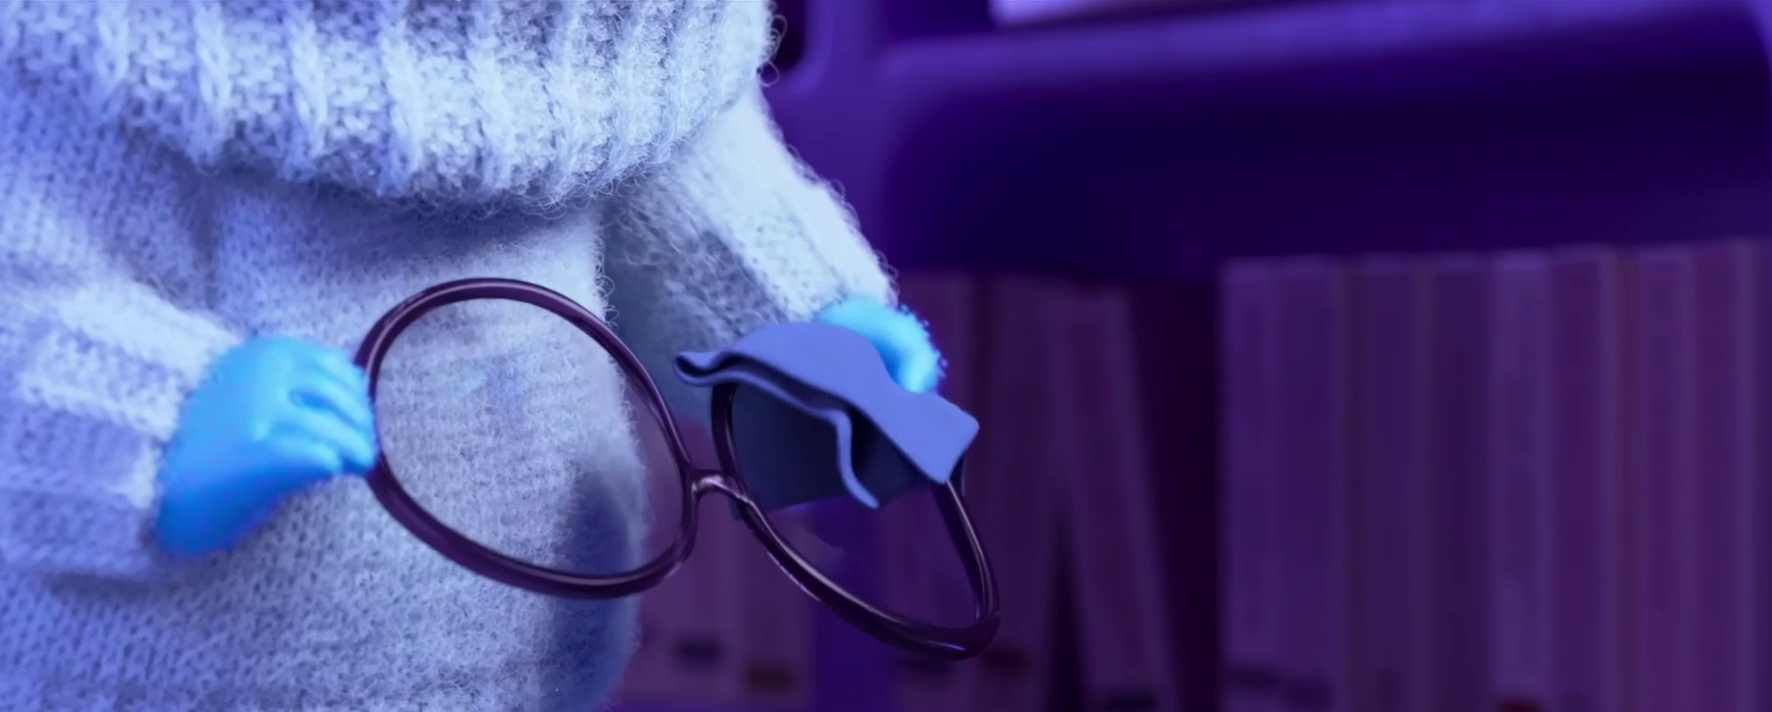

In [38]:
draw_annotated_frames(result_df, frame_df)

from IPython.display import Image as IPyImage, display as ipy_display
sample_annotated = None
for frame_id in frame_df['frame_id']:
    p = f'{OUTPUT_DIR}/annotated_frames/frame_{int(frame_id):05d}.jpg'
    if os.path.exists(p):
        sample_annotated = p
        break

if sample_annotated:
    ipy_display(IPyImage(filename=sample_annotated, width=700))
else:
    print('표시할 annotated frame이 없습니다.')

## 8-1. 하이라이트 점수 계산 실행

In [39]:
score_df = calculate_highlight_scores(result_df, window_size=WINDOW_SIZE, step_size=STEP_SIZE)
display(score_df.head(10))


[5단계] 하이라이트 점수 계산
하이라이트 점수 저장 완료: /content/drive/MyDrive/인지프/insideout2_output/highlight_scores.csv
     start_sec  end_sec start_time end_time  num_detections  character_count  \
80         785      790      13:05    13:10              12                9   
116       1330     1335      22:10    22:15               8                4   
79         780      785      13:00    13:05              24                7   
38         425      430      07:05    07:10               7                4   
60         605      610      10:05    10:10               6                5   
47         510      515      08:30    08:35               6                5   
88         845      850      14:05    14:10               8                4   
76         750      755      12:30    12:35              10                7   
7           80       85      01:20    01:25               4                4   
100       1065     1070      17:45    17:50               6                5   

     emotion_count

,start_sec,end_sec,start_time,end_time,num_detections,character_count,emotion_count,avg_mismatch,emotion_entropy,transition_score,avg_emotion_confidence,highlight_score
80,785,790,13:05,13:10,12,9,3,0.800000,0.519759,0.6,0.479934,0.709940
116,1330,1335,22:10,22:15,8,4,2,0.687500,0.356207,0.8,0.482365,0.638427
79,780,785,13:00,13:05,24,7,2,0.537500,0.339976,1.0,0.405292,0.626869
38,425,430,07:05,07:10,7,4,2,0.685714,0.350945,0.6,0.443106,0.596308
60,605,610,10:05,10:10,6,5,5,0.566667,0.802046,0.2,0.336653,0.595512
47,510,515,08:30,08:35,6,5,3,0.683333,0.564575,0.2,0.428174,0.588644
88,845,850,14:05,14:10,8,4,3,0.500000,0.556138,0.6,0.456891,0.564035
76,750,755,12:30,12:35,10,7,2,0.550000,0.313922,0.6,0.316111,0.545981
7,80,85,01:20,01:25,4,4,3,0.725000,0.534311,0.0,0.280348,0.539828
100,1065,1070,17:45,17:50,6,5,2,0.700000,0.327104,0.2,0.493588,0.536776


작업일: 2026-05-30
- Youtube 'Most Replayed' Data 조회 실행

## 5초 확장 데이터셋: `final_highlight_dataset_5sec_enhanced.csv`

기존 4개 특성 외에 아래 입력 특성을 추가합니다.

- `emotion_confidence_score`: CLIP 예측 확률의 평균
- `expected_emotion_probability`: 캐릭터가 원래 대표하는 감정에 CLIP이 부여한 평균 확률
- `emotion_intensity_score`: 예측 확률 분포를 반영한 감정 흥분도
- `emotion_distance_score`: 기대 감정과 예측 감정의 valence-arousal 거리
- `valence_flip_rate`: 긍정·부정 방향이 뒤집힌 탐지 비율
- `arousal_change_score`: 기대 감정 대비 흥분도 변화량
- `emotion_change_count`, `emotion_change_rate`: 구간 안에서 감정이 바뀐 횟수와 비율
- `character_emotion_rarity_score`: 해당 캐릭터의 과거 기록에서 드물었던 감정인지 나타내는 점수
- `mismatch_delta`, `entropy_delta`: 직전 5초 대비 변화량
- `dominant_emotion_changed`: 대표 감정이 직전 구간과 달라졌는지 여부
- `surprise_spike`: 직전 15초 평균보다 mismatch가 갑자기 증가한 정도
- `rolling_mismatch_mean_15sec`, `rolling_entropy_std_15sec`: 최근 15초 맥락
- `high_mismatch_duration_sec`: 높은 mismatch가 연속된 시간

시간 맥락 특성은 현재 및 이전 구간만 사용하므로 미래 정보 누수를 피합니다.


In [40]:
youtube_url = "https://www.youtube.com/watch?v=vW0IQoSweVI"
# youtube_url = input("하이라이트 클립을 추출할 YouTube 영상 URL을 입력하세요: ")

In [41]:
try:
    video_id = extract_video_id(youtube_url)

    youtube_replayed_data = get_heatmap_svg_path_with_selenium(youtube_url)

    if youtube_replayed_data is None:
        raise ValueError("YouTube heatmap 데이터를 가져오지 못했습니다.")

    highlight_df = pd.read_csv(f"{OUTPUT_DIR}/highlight_scores.csv")
    duration_sec = highlight_df["end_sec"].max()

    second_df = svg_path_d_to_second_level_replay_df(
        d=youtube_replayed_data,
        duration_sec=duration_sec
    )

    print(f"second min: {second_df['second'].min()}, second max: {second_df['second'].max()}")
    print(
        "replay score min:",
        second_df["youtube_replay_score"].min(),
        "replay score max:",
        second_df["youtube_replay_score"].max()
    )

    display(second_df.head())

    final_dataset = make_enhanced_highlight_dataset(
        emotion_csv_path=f"{OUTPUT_DIR}/character_emotion_results.csv",
        youtube_second_df=second_df,
        video_id=video_id,
        output_path=f"{OUTPUT_DIR}/final_highlight_dataset_5sec_enhanced.csv",
        segment_sec=5,
        highlight_threshold=0.6,
        high_mismatch_threshold=0.6,
    )

    display(final_dataset.head())
    print("Final dataset saved:", f"{OUTPUT_DIR}/final_highlight_dataset_5sec_enhanced.csv")

except Exception as e:
    print(f"An error occurred: {e}")


second min: 0, second max: 1755
replay score min: 0.00016355386726112087 replay score max: 0.9956051493088528


,second,youtube_replay_score
0,0,0.022222
1,1,0.088171
2,2,0.197293
3,3,0.439459
4,4,0.566496


,video_id,segment_id,segment_sec,start_time,end_time,character,expected_emotion,predicted_emotion,detection_count,character_count,...,character_emotion_rarity_score,youtube_highlight_score,is_highlight,mismatch_delta,entropy_delta,dominant_emotion_changed,surprise_spike,rolling_mismatch_mean_15sec,rolling_entropy_std_15sec,high_mismatch_duration_sec
0,vW0IQoSweVI,1,5,0,5,None,None,None,0,0,...,0.0,0.262728,0,0.0,0.0,0,0.0,0.0,0.0,0
1,vW0IQoSweVI,2,5,5,10,None,None,None,0,0,...,0.0,0.588119,0,0.0,0.0,0,0.0,0.0,0.0,0
2,vW0IQoSweVI,3,5,10,15,None,None,None,0,0,...,0.0,0.623612,1,0.0,0.0,0,0.0,0.0,0.0,0
3,vW0IQoSweVI,4,5,15,20,Anger,angry,surprised,1,1,...,0.0,0.427657,0,0.6,-0.0,0,0.6,0.2,0.0,5
4,vW0IQoSweVI,5,5,20,25,None,None,None,0,0,...,0.0,0.243272,0,-0.6,0.0,0,0.0,0.2,0.0,0


Final dataset saved: /content/drive/MyDrive/인지프/insideout2_output/final_highlight_dataset_5sec_enhanced.csv


## 9-1. 시각화 그래프 생성 실행


[6단계] 시각화 그래프 생성
시각화 저장 완료
/content/drive/MyDrive/인지프/insideout2_output/emotion_distribution_by_character.png


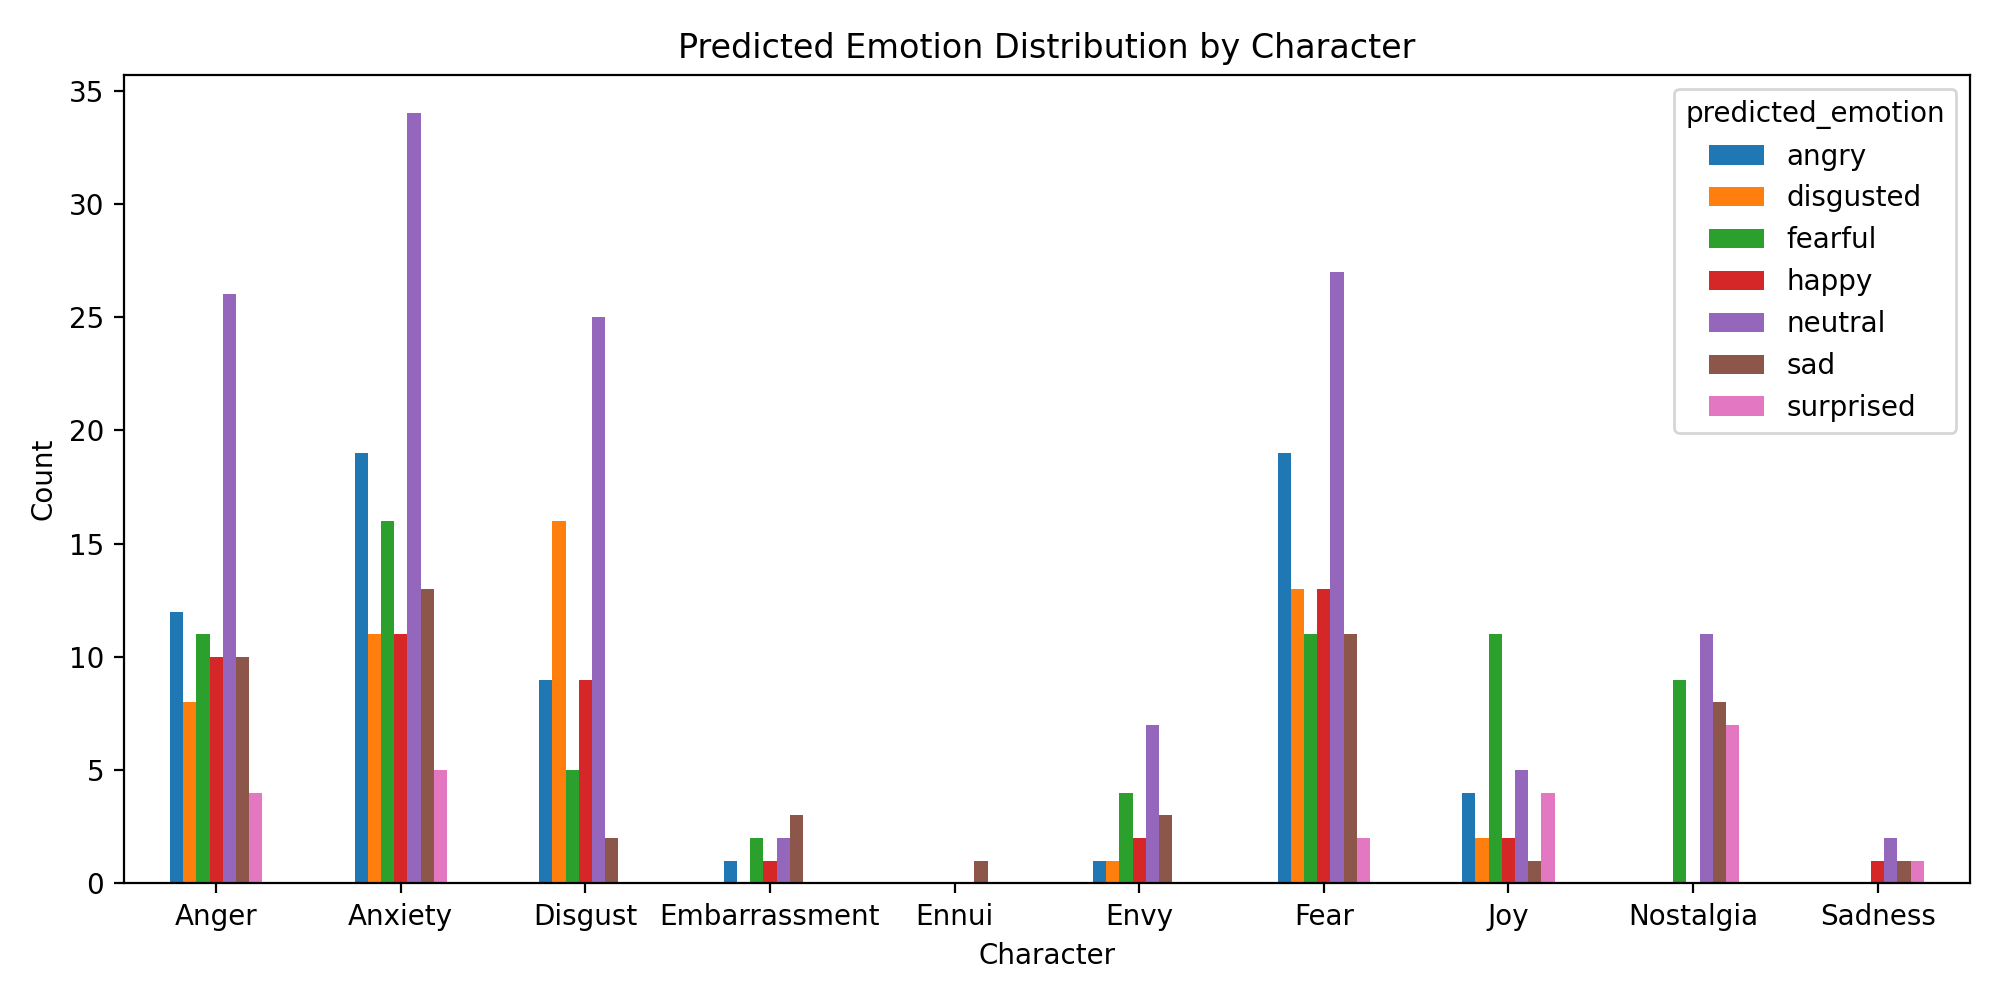

/content/drive/MyDrive/인지프/insideout2_output/mismatch_score_timeline.png


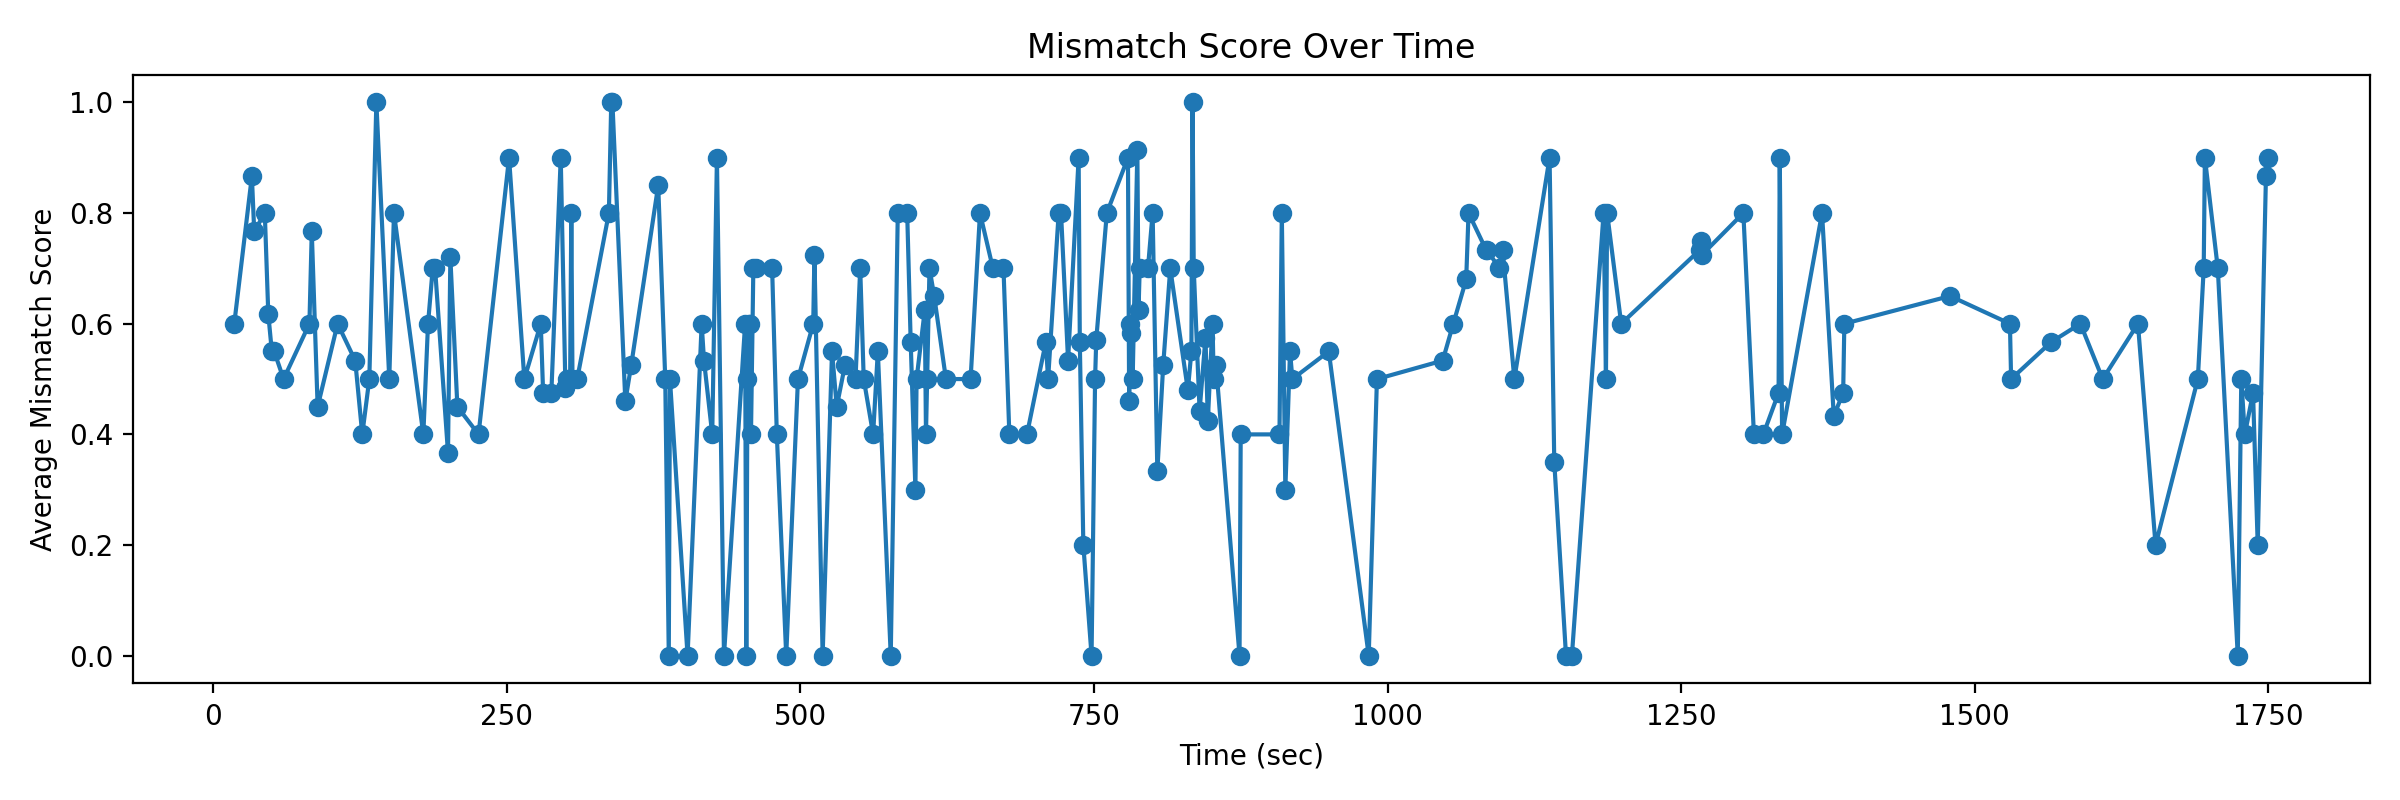

/content/drive/MyDrive/인지프/insideout2_output/highlight_score_timeline.png


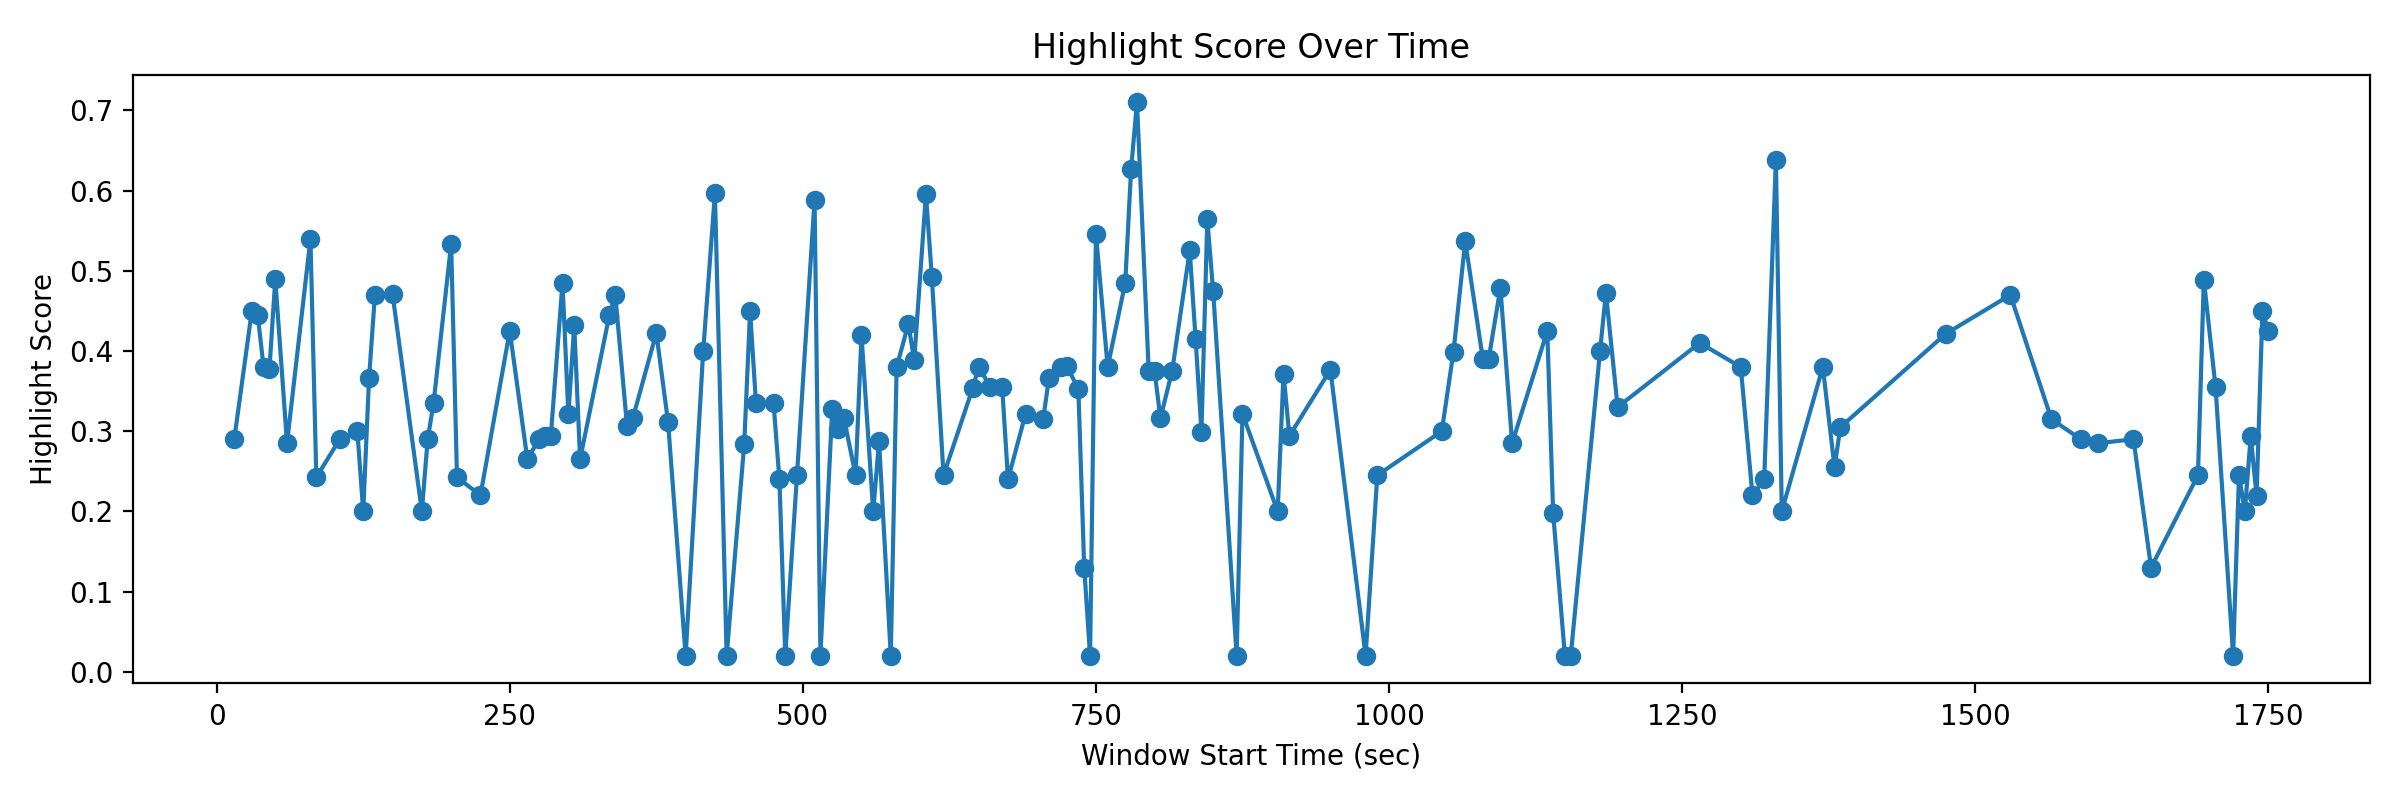

In [42]:
make_visualizations(result_df, score_df)

from IPython.display import Image as IPyImage, display as ipy_display
for p in [
    f'{OUTPUT_DIR}/emotion_distribution_by_character.png',
    f'{OUTPUT_DIR}/mismatch_score_timeline.png',
    f'{OUTPUT_DIR}/highlight_score_timeline.png',
]:
    if os.path.exists(p):
        print(p)
        ipy_display(IPyImage(filename=p, width=800))

## 10-1. 하이라이트 클립 및 결과 영상 생성 실행

In [43]:
top_highlights_df = extract_highlight_clips(VIDEO_PATH, score_df, top_k=TOP_K_HIGHLIGHTS, clip_margin=2)
make_annotated_video(frame_df, f'{OUTPUT_DIR}/annotated_demo_video.mp4', fps=SAMPLE_FPS)
display(top_highlights_df)


[7단계] 하이라이트 후보 클립 추출
하이라이트 클립 저장: /content/drive/MyDrive/인지프/insideout2_output/highlight_clips/highlight_80_score_0.710.mp4
하이라이트 클립 저장: /content/drive/MyDrive/인지프/insideout2_output/highlight_clips/highlight_116_score_0.638.mp4
하이라이트 클립 저장: /content/drive/MyDrive/인지프/insideout2_output/highlight_clips/highlight_79_score_0.627.mp4

[8단계] annotated demo video 생성
annotated video 저장 완료: /content/drive/MyDrive/인지프/insideout2_output/annotated_demo_video.mp4


,start_sec,end_sec,start_time,end_time,num_detections,character_count,emotion_count,avg_mismatch,emotion_entropy,transition_score,avg_emotion_confidence,highlight_score
80,785,790,13:05,13:10,12,9,3,0.8000,0.519759,0.6,0.479934,0.709940
116,1330,1335,22:10,22:15,8,4,2,0.6875,0.356207,0.8,0.482365,0.638427
79,780,785,13:00,13:05,24,7,2,0.5375,0.339976,1.0,0.405292,0.626869


## 11-1. 요약 리포트 생성 실행

In [44]:
make_summary_report(result_df, score_df)
report_path = f'{OUTPUT_DIR}/summary_report.txt'
with open(report_path, 'r', encoding='utf-8') as f:
    print(f.read())


[9단계] 요약 리포트 생성
요약 리포트 저장 완료: /content/drive/MyDrive/인지프/insideout2_output/summary_report.txt
Inside Out 2 감정 캐릭터 표정 분석 데모 리포트

[분석 대상 캐릭터]
- Joy(기쁨): 기대 감정 = happy
- Sadness(슬픔): 기대 감정 = sad
- Anger(분노): 기대 감정 = angry
- Fear(두려움): 기대 감정 = fearful
- Disgust(불쾌): 기대 감정 = disgusted
- Anxiety(불안): 기대 감정 = surprised
- Envy(질투): 기대 감정 = disgusted
- Embarrassment(창피): 기대 감정 = surprised
- Ennui(권태): 기대 감정 = neutral
- Nostalgia(향수): 기대 감정 = neutral

[전체 탐지 결과]
- 총 탐지 crop 수: 449
- 등장 캐릭터 수: 10

[캐릭터별 탐지 수]
character
Anxiety          109
Fear              96
Anger             81
Disgust           66
Nostalgia         35
Joy               29
Envy              18
Embarrassment      9
Sadness            5
Ennui              1

[예측 감정 분포]
predicted_emotion
neutral      139
fearful       69
angry         65
sad           53
disgusted     51
happy         49
surprised     23

[평균 Mismatch Score]
0.5672605790645879

[상위 하이라이트 후보]
- 13:05 ~ 13:10 | Highlight Score=0.710, Mismatch=0.800, Emotion Entrop

## 12. 최종 결과 파일 확인

In [45]:
print('전체 완료!')
print(f'결과 폴더: {OUTPUT_DIR}')
print('\n주요 결과 파일')
print(f'- {OUTPUT_DIR}/character_emotion_results.csv')
print(f'- {OUTPUT_DIR}/highlight_scores.csv')
print(f'- {OUTPUT_DIR}/summary_report.txt')
print(f'- {OUTPUT_DIR}/annotated_demo_video.mp4')
print(f'- {OUTPUT_DIR}/emotion_distribution_by_character.png')
print(f'- {OUTPUT_DIR}/mismatch_score_timeline.png')
print(f'- {OUTPUT_DIR}/highlight_score_timeline.png')
print(f'- {OUTPUT_DIR}/highlight_clips/')

전체 완료!
결과 폴더: /content/drive/MyDrive/인지프/insideout2_output

주요 결과 파일
- /content/drive/MyDrive/인지프/insideout2_output/character_emotion_results.csv
- /content/drive/MyDrive/인지프/insideout2_output/highlight_scores.csv
- /content/drive/MyDrive/인지프/insideout2_output/summary_report.txt
- /content/drive/MyDrive/인지프/insideout2_output/annotated_demo_video.mp4
- /content/drive/MyDrive/인지프/insideout2_output/emotion_distribution_by_character.png
- /content/drive/MyDrive/인지프/insideout2_output/mismatch_score_timeline.png
- /content/drive/MyDrive/인지프/insideout2_output/highlight_score_timeline.png
- /content/drive/MyDrive/인지프/insideout2_output/highlight_clips/


### 하이라이트 저장안됨 -> 해결

In [46]:
import os

print("현재 작업 폴더:")
print(os.getcwd())

print("\n결과 폴더 절대경로:")
print(os.path.abspath("insideout2_output"))

print("\n결과 폴더 안 파일:")
print(os.listdir("insideout2_output"))


현재 작업 폴더:
/content/drive/MyDrive/인지프

결과 폴더 절대경로:
/content/drive/MyDrive/인지프/insideout2_output

결과 폴더 안 파일:
['frames', 'crops', 'annotated_frames', 'highlight_clips', 'dropped_blur_frames', 'dropped_light_frames', 'dropped_duplicate_frames', 'extracted_frames.csv', 'dropped_blur_frames.csv', 'dropped_light_frames.csv', 'dropped_duplicate_frames.csv', 'character_emotion_results.csv', 'highlight_scores.csv', 'final_highlight_dataset_5sec_enhanced.csv', 'emotion_distribution_by_character.png', 'mismatch_score_timeline.png', 'highlight_score_timeline.png', 'annotated_demo_video.mp4', 'summary_report.txt']


In [47]:
from pathlib import Path

out_dir = Path("insideout2_output")
clip_dir = out_dir / "highlight_clips"

print("결과 폴더 존재:", out_dir.exists())
print("highlight_clips 폴더 존재:", clip_dir.exists())

if clip_dir.exists():
    files = list(clip_dir.glob("*"))
    print("highlight_clips 안 파일 수:", len(files))
    for f in files:
        print(f)


결과 폴더 존재: True
highlight_clips 폴더 존재: True
highlight_clips 안 파일 수: 3
insideout2_output/highlight_clips/highlight_80_score_0.710.mp4
insideout2_output/highlight_clips/highlight_116_score_0.638.mp4
insideout2_output/highlight_clips/highlight_79_score_0.627.mp4


In [48]:
import pandas as pd
from pathlib import Path

score_path = Path("insideout2_output/highlight_scores.csv")

print("highlight_scores.csv 존재:", score_path.exists())

if score_path.exists():
    score_df = pd.read_csv(score_path)
    display(score_df.sort_values("highlight_score", ascending=False).head(10))
else:
    print("먼저 하이라이트 점수 계산 셀을 실행해야 해.")


highlight_scores.csv 존재: True


,start_sec,end_sec,start_time,end_time,num_detections,character_count,emotion_count,avg_mismatch,emotion_entropy,transition_score,avg_emotion_confidence,highlight_score
0,785,790,13:05,13:10,12,9,3,0.800000,0.519759,0.6,0.479934,0.709940
1,1330,1335,22:10,22:15,8,4,2,0.687500,0.356207,0.8,0.482365,0.638427
2,780,785,13:00,13:05,24,7,2,0.537500,0.339976,1.0,0.405292,0.626869
3,425,430,07:05,07:10,7,4,2,0.685714,0.350945,0.6,0.443106,0.596308
4,605,610,10:05,10:10,6,5,5,0.566667,0.802046,0.2,0.336653,0.595512
5,510,515,08:30,08:35,6,5,3,0.683333,0.564575,0.2,0.428174,0.588644
6,845,850,14:05,14:10,8,4,3,0.500000,0.556138,0.6,0.456891,0.564035
7,750,755,12:30,12:35,10,7,2,0.550000,0.313922,0.6,0.316111,0.545981
8,80,85,01:20,01:25,4,4,3,0.725000,0.534311,0.0,0.280348,0.539828
9,1065,1070,17:45,17:50,6,5,2,0.700000,0.327104,0.2,0.493588,0.536776


In [49]:
import shutil

print("ffmpeg 위치:", shutil.which("ffmpeg"))

ffmpeg 위치: /usr/bin/ffmpeg


In [50]:
%pip install imageio-ffmpeg

In [51]:
import imageio_ffmpeg

FFMPEG_EXE = imageio_ffmpeg.get_ffmpeg_exe()
print(FFMPEG_EXE)

/usr/local/lib/python3.12/dist-packages/imageio_ffmpeg/binaries/ffmpeg-linux-x86_64-v7.0.2


In [52]:
import os
import subprocess
import pandas as pd
from pathlib import Path
import imageio_ffmpeg

VIDEO_PATH = "인사이드아웃요약.mp4"
OUTPUT_DIR = "insideout2_output"

def extract_highlight_clips_fixed(video_path, score_csv, output_dir, top_k=3, clip_margin=2):
    ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()

    score_df = pd.read_csv(score_csv)
    score_df = score_df.sort_values("highlight_score", ascending=False).reset_index(drop=True)

    clip_dir = Path(output_dir) / "highlight_clips"
    clip_dir.mkdir(parents=True, exist_ok=True)

    top_df = score_df.head(top_k).copy()

    print("저장할 하이라이트 후보 구간")
    display(top_df[["start_time", "end_time", "highlight_score", "avg_mismatch", "emotion_entropy"]])

    saved_files = []

    for i, row in top_df.iterrows():
        start = max(0, float(row["start_sec"]) - clip_margin)
        end = float(row["end_sec"]) + clip_margin
        duration = end - start

        out_path = clip_dir / f"highlight_top{i+1}_score_{row['highlight_score']:.3f}.mp4"

        cmd = [
            ffmpeg_exe,
            "-y",
            "-ss", str(start),
            "-i", video_path,
            "-t", str(duration),
            "-c:v", "libx264",
            "-c:a", "aac",
            str(out_path)
        ]

        print("\n실행 명령어:")
        print(" ".join(cmd))

        result = subprocess.run(
            cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True
        )

        if out_path.exists() and out_path.stat().st_size > 0:
            print("저장 성공:", out_path)
            saved_files.append(out_path)
        else:
            print("저장 실패:", out_path)
            print("ffmpeg 에러 메시지 일부:")
            print(result.stderr[-1000:])

    return saved_files, top_df


saved_files, top_df = extract_highlight_clips_fixed(
    video_path=VIDEO_PATH,
    score_csv="insideout2_output/highlight_scores.csv",
    output_dir=OUTPUT_DIR,
    top_k=3,
    clip_margin=2
)

print("\n최종 저장된 파일:")
for f in saved_files:
    print(f)


저장할 하이라이트 후보 구간


,start_time,end_time,highlight_score,avg_mismatch,emotion_entropy
0,13:05,13:10,0.709940,0.8000,0.519759
1,22:10,22:15,0.638427,0.6875,0.356207
2,13:00,13:05,0.626869,0.5375,0.339976



실행 명령어:
/usr/local/lib/python3.12/dist-packages/imageio_ffmpeg/binaries/ffmpeg-linux-x86_64-v7.0.2 -y -ss 783.0 -i 인사이드아웃요약.mp4 -t 9.0 -c:v libx264 -c:a aac insideout2_output/highlight_clips/highlight_top1_score_0.710.mp4
저장 성공: insideout2_output/highlight_clips/highlight_top1_score_0.710.mp4

실행 명령어:
/usr/local/lib/python3.12/dist-packages/imageio_ffmpeg/binaries/ffmpeg-linux-x86_64-v7.0.2 -y -ss 1328.0 -i 인사이드아웃요약.mp4 -t 9.0 -c:v libx264 -c:a aac insideout2_output/highlight_clips/highlight_top2_score_0.638.mp4
저장 성공: insideout2_output/highlight_clips/highlight_top2_score_0.638.mp4

실행 명령어:
/usr/local/lib/python3.12/dist-packages/imageio_ffmpeg/binaries/ffmpeg-linux-x86_64-v7.0.2 -y -ss 778.0 -i 인사이드아웃요약.mp4 -t 9.0 -c:v libx264 -c:a aac insideout2_output/highlight_clips/highlight_top3_score_0.627.mp4
저장 성공: insideout2_output/highlight_clips/highlight_top3_score_0.627.mp4

최종 저장된 파일:
insideout2_output/highlight_clips/highlight_top1_score_0.710.mp4
insideout2_output/highlight_clips/hig